## PD Model â€” Home Credit Default Risk (Multi-stream LSTM)
### Four-stream LSTM vs LightGBM vs Logistic Regression â€” Out-of-time validation
### Out-of-time validation across full-population, repayment-bureau, has-bureau, and no-bureau segments. Dual segmentation.

**Purpose:** Production-quality probability-of-default model using a
**four-stream LSTM** on installment payment, bureau balance, credit card
sequences, POS/cash loan, plus static origination features.
BASE dataset: `/kaggle/input/competitions/home-credit-default-risk/`

**Workflow:** `kaggle kernels push -p notebooks` -> run on Kaggle ->
`kaggle kernels output <id> -p ./kaggle_outputs`. Environment auto-detect:
local runs use `nrows=5000` for local test run; Kaggle runs use full data.

## Problem framing and stream selection

Static origination features alone miss borrower trajectory: a snapshot at
application time cannot capture whether someone pays on time, underpays, or
how their bureau status evolves over time.

### Behavioral streams feeding the Quad LSTM

The default **4-stream Quad LSTM** learns sequences from four Home Credit tables.
Each stream carries independent default signal:

- **`installments_payments` (installment payments)** â€” payment delay and payment ratio per instalment;
  capturing whether a borrower consistently underpays or pays late.
- **`bureau_balance` + `bureau` (bureau balance status)** â€” monthly bureau status codes (0-5, C, X) encoding
  delinquency escalation across all external credit accounts.
- **`credit_card_balance` (credit card utilization and DPD)** â€” revolving balance utilization and
  days-past-due per statement month.
- **`POS_CASH_balance` (POS/cash completion ratio and DPD)** â€” monthly completion ratio
  (remaining instalments / scheduled) and a days-past-due flag.

I model these with the default **4-stream Quad LSTM**, so past delinquency
signal can stay "alive" across time (a delinquency event 18 months ago still
has impact even after later clean months). Static origination features
(income ratios, external credit scores, employment) are concatenated at the end
for the final risk score.

**POS/cash is the fourth LSTM stream in the default Quad model; evidence and the
stream-selection decision are in `paper_lstm_stream_selection_by_loo.ipynb`.**

**Selection process (two steps):**

1. **Coverage and business relevance screening:** Each candidate stream must cover a material fraction of the target portfolio and encode direct repayment behaviour or delinquency escalation. All four pass.

2. **LOO (leave-one-out) stream selection with statistical validation:** Leave-one-out stream removal tests, DeLong paired tests, embedding orthogonality, and Integrated Gradients attribution are fully documented in `paper_lstm_stream_selection_by_loo.ipynb`. That notebook is the source of truth for all stream-retention decisions.

**Conclusion:** All four streams (installment, bureau, credit card, POS/cash) are retained in the QuadLSTMModel. See the **Stream Selection Decision** section later in this notebook and the LOO paper for the full evidence table.

### Two segmentation dimensions evaluated throughout

1. **Repayment-bureau segmentation** â€” borrowers with both installment payment
   AND bureau records (`has_repayment_bureau`, n=88,816) trained and evaluated
   separately from the full pool. The complement â€” borrowers lacking installment
   history, bureau records, or both â€” is the `no_repayment_bureau` population
   (n=218,695, 71% of pool), excluded from this focused experiment.
2. **Bureau-presence segmentation** â€” within the full 307K population, borrowers
   with at least one behavioral sequence (`has_bureau`, has_seq_flag=1, n~295K)
   versus those with none (`no_bureau`, has_seq_flag=0, n~12K). Both sub-segments
   are evaluated without retraining.

### Baseline design

Three baselines are evaluated against the LSTM across all experiments:
- **Logistic Regression (LR):** The regulatory-standard scorecard baseline.
  Interpretable and transparent; the dominant production model in SE Asian
  consumer lending. Regulatory capital adequacy frameworks and model governance standards in many jurisdictions
  require interpretable model documentation for retail credit scoring. LR remains the dominant production model for this reason.
  Any LSTM deployment must demonstrate OOT lift over LR.
- **LightGBM:** The ML challenger baseline. Gradient-boosted trees on the same
  static features confirm whether non-linear interactions add value before
  attributing lift to sequential modelling.
- **Quad LSTM (4-stream):** Sequential behavioral model over installment payments,
  bureau balance, credit card, and POS/cash streams. Stream retention is evidenced in
  `paper_lstm_stream_selection_by_loo.ipynb`.

All three baselines use identical feature sets, OOT split methodology, and leakage controls.


### Why only four LSTM streams (out of seven Kaggle files)?

The public Home Credit Default Risk dataset ships **seven main tables**:

1. `application_train` / `application_test` - static origination snapshot per application.
2. `bureau` + `bureau_balance` - external bureau accounts and monthly delinquency status.
3. `installments_payments` - per-instalment repayment events.
4. `credit_card_balance` - monthly card utilization / DPD.
5. `POS_CASH_balance` - monthly POS/cash loan status / DPD.
6. `previous_application` - past applications for other products.

For sequential modelling, this notebook makes a deliberate distinction between:

- **Behavioral sequence candidates** - tables with a clear time index, multiple rows per borrower, and long-enough trajectories to justify an LSTM:
  - `installments_payments`, `bureau_balance` (joined with `bureau`), `credit_card_balance`, `POS_CASH_balance`.
- **Static feature sources** - tables whose information is better captured via aggregations at application time:
  - `application_train` / `application_test` (one row per loan),
  - `previous_application` (short, heterogeneous history of prior applications).

Concretely:

- `application_train` and `application_test` are **by design static**; their fields (income, product type, region, etc.) are used in the `STATIC_COLS` block and so are included in all models (static-only MLP and the quad-stream LSTM).
- `previous_application` is intentionally **aggregated into static features** (counts / amounts / ratios). When I compare the **static-only MLP** against the **four-stream LSTM**, I am measuring the incremental value of behavioral sequences **on top of** all static features, including any information derived from `previous_application`.
- Only the four behavioural credit-history tables are turned into LSTM streams via `build_installment_sequences`, `build_bureau_sequences`, `build_cc_sequences`, and `build_pos_sequences`.

The **stream-selection LOO study** therefore answers a focused question: *"Given all static information from all seven files, which behavioural tables merit their own LSTM stream?"* The results show that installments, bureau, credit card, and POS/cash each clear the pre-defined Delta AUC / Delta KS thresholds, while the remaining three Kaggle tables are appropriately handled as static inputs rather than separate streams.

In [1]:
# Stream selection decision: see paper_lstm_stream_selection_by_loo.ipynb
# All four streams (installment, bureau, credit card, POS/cash) are retained.
# Bureau retention rationale: IG attribution ~20% (see LOO paper Cell 18 live output),
# orthogonal embeddings, population coverage for no-bureau borrowers, and model governance.
# Non-significant DeLong p (see LOO paper Cell 11 live output) does not justify removal.
# Source of truth: paper_lstm_stream_selection_by_loo.ipynb Sections 1-4.
print("Stream selection: 4-stream QuadLSTMModel (inst + bureau + CC + POS). See LOO paper.")


Stream selection: 4-stream QuadLSTMModel (inst + bureau + CC + POS). See LOO paper.


In [2]:
import os
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    BASE = '/kaggle/input/competitions/home-credit-default-risk/'
else:
    for candidate in ('./data/home_credit', '../data/home_credit'):
        p = os.path.join(os.path.abspath(candidate), 'application_train.csv')
        if os.path.exists(p):
            BASE = os.path.abspath(candidate) + os.sep
            break
    else:
        BASE = os.path.abspath('./data/home_credit') + os.sep
MAX_SEQ_LEN = 24
STATIC_COLS = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT',
    'credit_annuity_ratio', 'credit_goods_ratio', 'credit_downpayment', 'annuity_income_ratio'
]
READ_NROWS = None if IS_KAGGLE else 5000

_base_display = BASE
if not IS_KAGGLE and BASE:
    try:
        from pathlib import Path as _P
        _base_display = str(_P(BASE).resolve().relative_to(_P.cwd().resolve()))
    except ValueError:
        _base_display = BASE
print(f'Environment: {"Kaggle" if IS_KAGGLE else "Local"}  |  BASE: {_base_display}')
if not IS_KAGGLE:
    print('[LOCAL] READ_NROWS=5000 for fast run. On Kaggle, full data is used.')


Environment: Kaggle  |  BASE: /kaggle/input/competitions/home-credit-default-risk/


## Data Loading

In [3]:
def load_data(base: str, nrows=None):
    """Load application_train, installments_payments, bureau_balance, bureau, POS_CASH_balance. nrows caps rows per file when provided (local dev)."""
    kw = {} if nrows is None else {'nrows': nrows}
    app = pd.read_csv(os.path.join(base, 'application_train.csv'), **kw)
    inst = pd.read_csv(os.path.join(base, 'installments_payments.csv'), **kw)
    bur_b = pd.read_csv(os.path.join(base, 'bureau_balance.csv'), **kw)
    bur = pd.read_csv(os.path.join(base, 'bureau.csv'), **kw)
    pos = pd.read_csv(os.path.join(base, 'POS_CASH_balance.csv'), **kw)
    prev_app = pd.read_csv(os.path.join(base, 'previous_application.csv'), **kw)
    cc = pd.read_csv(os.path.join(base, 'credit_card_balance.csv'), **kw)
    return app, inst, bur_b, bur, pos, prev_app, cc

app, inst, bur_b, bur, pos, prev_app, cc = load_data(BASE, nrows=READ_NROWS)
print('application_train:', app.shape, '| cols (first 8):', list(app.columns[:8]))
print('installments_payments:', inst.shape, '| cols:', list(inst.columns[:8]))
print('bureau_balance:', bur_b.shape, '| cols:', list(bur_b.columns))
print('bureau:', bur.shape, '| cols (first 8):', list(bur.columns[:8]))
print('POS_CASH_balance:', pos.shape, '| cols:', list(pos.columns))
print('previous_application:', prev_app.shape, '| cols (first 8):', list(prev_app.columns[:8]))
print('credit_card_balance:', cc.shape, '| cols:', list(cc.columns[:8]))

application_train: (307511, 122) | cols (first 8): ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']
installments_payments: (13605401, 8) | cols: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']
bureau_balance: (27299925, 3) | cols: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']
bureau: (1716428, 17) | cols (first 8): ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT']
POS_CASH_balance: (10001358, 8) | cols: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
previous_application: (1670214, 37) | cols (first 8): ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYME

In [4]:
# Engineered static features on app (in-place); clip to 1st-99th percentile
app['credit_annuity_ratio'] = app['AMT_CREDIT'] / (app['AMT_ANNUITY'] + 1e-6)
app['credit_goods_ratio'] = app['AMT_CREDIT'] / (app['AMT_GOODS_PRICE'] + 1e-6)
app['credit_downpayment'] = app['AMT_GOODS_PRICE'] - app['AMT_CREDIT']
app['annuity_income_ratio'] = app['AMT_ANNUITY'] / (app['AMT_INCOME_TOTAL'] + 1e-6)
for col in ['credit_annuity_ratio', 'credit_goods_ratio', 'credit_downpayment', 'annuity_income_ratio']:
    q01, q99 = app[col].quantile(0.01), app[col].quantile(0.99)
    app[col] = np.clip(app[col], q01, q99)
# TEMPORARY CLIP (full-population bounds).
# train-only re-clip is applied in the OOT split cell after split indices are known.
# Do not use these bounds for evaluation â€” they will be overwritten.
_CLIP_APPLIED = "full_population_temporary"
assert _CLIP_APPLIED == "full_population_temporary", (
    "Static feature clips must be re-applied on train-only bounds after OOT split. "
    "Verify the OOT split cell below overwrites these clips."
)
# Initial clip uses full-population percentiles (minor leakage at 80/20 split).
# Train-only re-clip is applied in the OOT split cell below.
# bounded by ~0.5-1.0% of rows). Train-only re-clip is applied at the OOT
# split cell (search for "_CLIP_APPLIED = 'train_only'"). For a strict no-leakage
# Note: move the clip computation inside the split cell using only tr_idx rows.
# Impact on AUC is negligible at 80/20 OOT splits (documented assumption).


## Feature Engineering

> **Clip leakage note:** Ratio features are clipped initially on full-population percentiles (minor leakage). Train-only bounds are re-applied at the OOT split cell before any model sees the data. Impact on AUC at 80/20 split is negligible and is documented as an accepted approximation.


In [5]:
# ---
# SEQUENCE CONVENTION (authoritative -- all four streams must match this spec)
# ---
#
# | Stream      | Sort key(s)                         | Ascending? | Window rule               |
# |-------------|-------------------------------------|------------|---------------------------|
# | installment | DAYS_INSTALMENT                     | True       | _rrank < MAX_SEQ_LEN      |
# | bureau      | MONTHS_BALANCE                      | True       | _rrank < MAX_SEQ_LEN      |
# | credit card | MONTHS_BALANCE                      | True       | _rrank < MAX_SEQ_LEN      |
# | POS/cash    | MONTHS_BALANCE                      | True       | _rrank < MAX_SEQ_LEN      |
#
# Padding:   PRE-PAD (zeros at start of window, most recent event at index -1)
# _rrank:    cumcount(ascending=False) assigns rank 0 to the most recent row per borrower
# _pos:      cumcount() after filtering assigns 0 to the oldest kept row in the window
# slot:      offset + _pos, where offset = MAX_SEQ_LEN - count_per_borrower
# Index 0:   oldest kept event (zero-padded if borrower has fewer than MAX_SEQ_LEN rows)
# Index -1:  most recent event (LSTM h_T emphasises recency)
#
# Rationale: pre-padding aligns the most recent timestep at position T
# across all streams so h_T carries a consistent temporal anchor.
# ---
_SEQUENCE_CONVENTION = {
    "padding":    "pre-pad (zeros at start)",
    "sort_order": "oldest-first (ascending sort key)",
    "window":     "_rrank < MAX_SEQ_LEN (keep last MAX_SEQ_LEN rows per borrower)",
    "index_0":    "oldest kept event",
    "index_T":    "most recent event",
}
assert MAX_SEQ_LEN == 24, (
    f"MAX_SEQ_LEN changed to {MAX_SEQ_LEN}. "
    "Update this block and all build_*_sequences functions consistently."
)
print("Sequence convention loaded. MAX_SEQ_LEN =", MAX_SEQ_LEN)
print("All four streams: oldest-first sort, pre-pad, index 0 = oldest kept slot.")


Sequence convention loaded. MAX_SEQ_LEN = 24
All four streams: oldest-first sort, pre-pad, index 0 = oldest kept slot.


In [6]:
def build_installment_sequences(inst: pd.DataFrame, max_seq_len: int):
    inst = inst.copy()
    inst['payment_delay'] = (
        inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
    ).fillna(180).clip(-30, 180)
    inst['payment_ratio'] = (
        inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1e-6)
    ).fillna(0.0).clip(0, 2)
    inst = inst.sort_values(['SK_ID_CURR', 'DAYS_INSTALMENT'])
    # Keep last max_seq_len rows per borrower (chronological tail)
    inst['_rrank'] = inst.groupby('SK_ID_CURR').cumcount(ascending=False)
    inst = inst[inst['_rrank'] < max_seq_len].copy()
    # Position within kept window (0 = oldest kept row)
    inst['_pos'] = inst.groupby('SK_ID_CURR').cumcount()
    ids = inst['SK_ID_CURR'].values
    uniq, inv, counts = np.unique(ids, return_inverse=True, return_counts=True)
    n = len(uniq)
    out_arr = np.zeros((n, max_seq_len, 2), dtype=np.float32)
    # Pre-pad: shift data to end of window so zeros are at the start
    offsets = max_seq_len - counts[inv]
    slot = offsets + inst['_pos'].values
    out_arr[inv, slot, 0] = inst['payment_delay'].values.astype(np.float32)
    out_arr[inv, slot, 1] = inst['payment_ratio'].values.astype(np.float32)
    return dict(zip(uniq.tolist(), out_arr))

inst_seqs = build_installment_sequences(inst, MAX_SEQ_LEN)
print('Installment sequences: %d borrowers' % len(inst_seqs))


Installment sequences: 339587 borrowers


In [7]:
def build_bureau_sequences(bur_b: pd.DataFrame, bur: pd.DataFrame, max_seq_len: int):
    STATUS_MAP = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, 'C': 6, 'X': 7}
    bb = bur_b.copy()
    bb['status_enc'] = bb['STATUS'].astype(str).map(STATUS_MAP).fillna(0).astype(np.float32)
    bb = bb.merge(bur[['SK_ID_BUREAU', 'SK_ID_CURR']], on='SK_ID_BUREAU', how='inner')
    # Oldest-first (ascending MONTHS_BALANCE), same temporal anchor as installments.
    # Pre-pad: zeros at start, most recent bureau month at end of window -- LSTM h_T emphasises recency.
    bb = bb.sort_values(['SK_ID_CURR', 'MONTHS_BALANCE'], ascending=[True, True])
    bb['_rrank'] = bb.groupby('SK_ID_CURR').cumcount(ascending=False)
    bb = bb[bb['_rrank'] < max_seq_len].copy()
    bb['_pos'] = bb.groupby('SK_ID_CURR').cumcount()
    ids = bb['SK_ID_CURR'].values
    uniq, inv, counts = np.unique(ids, return_inverse=True, return_counts=True)
    n = len(uniq)
    out_arr = np.zeros((n, max_seq_len, 1), dtype=np.float32)
    offsets = max_seq_len - counts[inv]
    slot = offsets + bb['_pos'].values
    out_arr[inv, slot, 0] = bb['status_enc'].values
    return dict(zip(uniq.tolist(), out_arr))

bureau_seqs = build_bureau_sequences(bur_b, bur, MAX_SEQ_LEN)
print('Bureau sequences: %d borrowers' % len(bureau_seqs))


Bureau sequences: 134542 borrowers


In [8]:
def build_cc_sequences(cc: pd.DataFrame, max_seq_len: int):
    """
    Per-borrower credit card balance sequences (vectorized).
    Features per timestep (2 features):
      utilization: AMT_BALANCE / (AMT_CREDIT_LIMIT_ACTUAL + 1e-6), fillna(0), clip(0, 1).
      dpd_flag: (SK_DPD > 0).astype(float), fillna(0).
    Sorted oldest-first (ascending MONTHS_BALANCE) + pre-padding so that
    zeros appear at the START of the window and the most recent CC month lands
    at position T -- consistent with build_installment_sequences and
    build_bureau_sequences (same temporal orientation as installment and bureau streams).
    Returns dict SK_ID_CURR -> np.array (max_seq_len, 2).
    """
    cc = cc.copy()
    cc['utilization'] = (
        cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-6)
    ).fillna(0).clip(0, 1).astype(np.float32)
    cc['dpd_flag'] = (cc['SK_DPD'].fillna(0) > 0).astype(np.float32)
    cc = cc.sort_values(['SK_ID_CURR', 'MONTHS_BALANCE'], ascending=[True, True])
    cc['_rrank'] = cc.groupby('SK_ID_CURR').cumcount(ascending=False)
    cc = cc[cc['_rrank'] < max_seq_len].copy()
    cc['_pos'] = cc.groupby('SK_ID_CURR').cumcount()
    ids_cc = cc['SK_ID_CURR'].values
    uniq_cc, inv_cc, counts_cc = np.unique(ids_cc, return_inverse=True, return_counts=True)
    n_cc = len(uniq_cc)
    out_arr = np.zeros((n_cc, max_seq_len, 2), dtype=np.float32)
    offsets_cc = max_seq_len - counts_cc[inv_cc]
    slot_cc = offsets_cc + cc['_pos'].values
    out_arr[inv_cc, slot_cc, 0] = cc['utilization'].values.astype(np.float32)
    out_arr[inv_cc, slot_cc, 1] = cc['dpd_flag'].values.astype(np.float32)
    return dict(zip(uniq_cc.tolist(), out_arr))

cc_seqs = build_cc_sequences(cc, MAX_SEQ_LEN)
print('CC sequences: %d borrowers' % len(cc_seqs))

CC sequences: 103558 borrowers


In [9]:
# POS/cash (fourth stream): build sequences before Repayment-Bureau / Quad training
# so the main notebook path matches the production QuadLSTMModel architecture.
def build_pos_sequences(pos: pd.DataFrame, max_seq_len: int):
    """
    Per-borrower POS/cash sequences (vectorized), oldest-first pre-padding.
    Features per timestep (2): completion_ratio, dpd_flag.
    """
    pos = pos.copy()
    pos['completion_ratio'] = (
        pos['CNT_INSTALMENT_FUTURE'] / (pos['CNT_INSTALMENT'].fillna(0) + 1e-6)
    ).fillna(0).clip(0, 1).astype(np.float32)
    pos['dpd_flag'] = (pos['SK_DPD'].fillna(0) > 0).astype(np.float32)
    pos = pos.sort_values(['SK_ID_CURR', 'MONTHS_BALANCE'], ascending=[True, True])
    pos['_rrank'] = pos.groupby('SK_ID_CURR').cumcount(ascending=False)
    pos = pos[pos['_rrank'] < max_seq_len].copy()
    pos['_pos'] = pos.groupby('SK_ID_CURR').cumcount()
    ids = pos['SK_ID_CURR'].values
    uniq, inv, counts = np.unique(ids, return_inverse=True, return_counts=True)
    seqs = np.zeros((len(uniq), max_seq_len, 2), dtype=np.float32)
    offsets = max_seq_len - counts[inv]
    slot = offsets + pos['_pos'].values
    seqs[inv, slot, 0] = pos['completion_ratio'].values
    seqs[inv, slot, 1] = pos['dpd_flag'].values
    result = {sk: seqs[i] for i, sk in enumerate(uniq)}
    print(f'POS sequences built: {len(result):,} borrowers')
    return result

pos_seqs = build_pos_sequences(pos, MAX_SEQ_LEN)


POS sequences built: 337,252 borrowers


In [10]:
def build_aligned_dataset(app, inst_seqs, bureau_seqs, cc_seqs):
    """Inner join on SK_ID_CURR (inst + bureau); CC is optional; missing borrowers get zero sequence.
    Returns ids, X_inst, X_bureau, X_cc, X_static_raw, y.
    Zero-padding for optional streams (cc): borrowers absent from cc_seqs receive an all-zeros sequence.
    Bureau stream: in the full-population experiment, no-bureau borrowers are identified by
    has_seq_flag=0 (see bureau-presence segmentation cell). Their bureau input is zero-padded, not imputed.
    The LSTM receives a valid signal of "no bureau history"."""
    app_ids = set(app['SK_ID_CURR'])
    # Inner join on inst + bureau only; CC is optional (left join semantics)
    common = sorted(app_ids & set(inst_seqs) & set(bureau_seqs))
    y = app.set_index('SK_ID_CURR').loc[common, 'TARGET'].values.astype(np.float32)
    X_inst = np.stack([inst_seqs[sk] for sk in common])
    X_bureau = np.stack([bureau_seqs[sk] for sk in common])
    zero_cc = np.zeros((MAX_SEQ_LEN, 2), dtype=np.float32)
    X_cc = np.stack([cc_seqs.get(sk, zero_cc) for sk in common])
    static_df = app.set_index('SK_ID_CURR').loc[common, [c for c in STATIC_COLS if c in app.columns]]
    for c in STATIC_COLS:
        if c not in static_df.columns:
            static_df[c] = np.nan
    X_static_raw = static_df[STATIC_COLS].values.astype(np.float32)
    print('Borrowers surviving join: %d | default rate: %.4f' % (len(common), y.mean()))
    return np.array(common), X_inst, X_bureau, X_cc, X_static_raw, y

ids, X_inst, X_bureau, X_cc, X_static_raw, y = build_aligned_dataset(app, inst_seqs, bureau_seqs, cc_seqs)
zero_pos = np.zeros((MAX_SEQ_LEN, 2), dtype=np.float32)
def _pos_row(sk):
    return pos_seqs.get(sk, pos_seqs.get(int(sk), zero_pos))
X_pos = np.stack([_pos_row(sk) for sk in ids])


Borrowers surviving join: 88816 | default rate: 0.0823


In [11]:
def split_and_scale(ids, X_inst, X_bureau, X_cc, X_pos, X_static_raw, y, test_size=0.2, random_state=42):
    """Stratified 80/20 split on y FIRST. Fit medians and StandardScaler on train only;
    transform train and val. Returns arrays + scaler + train_medians."""
    tr_idx, va_idx = train_test_split(np.arange(len(y)), test_size=test_size,
                                      random_state=random_state, stratify=y)
    train_medians = np.nanmedian(X_static_raw[tr_idx], axis=0)
    X_tr_static = np.where(np.isnan(X_static_raw[tr_idx]), train_medians, X_static_raw[tr_idx])
    X_va_static = np.where(np.isnan(X_static_raw[va_idx]), train_medians, X_static_raw[va_idx])
    scaler = StandardScaler()
    X_tr_static = scaler.fit_transform(X_tr_static)
    X_va_static = scaler.transform(X_va_static)
    return (
        ids[tr_idx], ids[va_idx],
        X_inst[tr_idx], X_inst[va_idx],
        X_bureau[tr_idx], X_bureau[va_idx],
        X_cc[tr_idx], X_cc[va_idx],
        X_pos[tr_idx], X_pos[va_idx],
        X_tr_static.astype(np.float32), X_va_static.astype(np.float32),
        y[tr_idx], y[va_idx],
        scaler, train_medians
    )

(
    ids_tr, ids_va,
    X_inst_tr, X_inst_va,
    X_bur_tr, X_bur_va,
    X_cc_tr, X_cc_va,
    X_pos_tr, X_pos_va,
    X_static_tr, X_static_va,
    y_tr, y_va,
    scaler, train_medians
) = split_and_scale(ids, X_inst, X_bureau, X_cc, X_pos, X_static_raw, y)
print('Train %d | Val %d' % (len(y_tr), len(y_va)))


Train 71052 | Val 17764


## Model Definition

### Architecture: QuadLSTMModel (default)

Four independent LSTM streams process borrower behavioral sequences in parallel.
Each stream receives a borrower's history as a padded tensor of shape
`(batch, max_seq_len, n_features)` and produces a fixed-size hidden state via
the final LSTM hidden unit:

| Stream | Input features | Hidden dim | Features encoded |
|---|---|---|---|
| Installment | 2 | 32 | payment_delay, payment_ratio |
| Bureau | 1 | 16 | status_enc (ordinal 0-7) |
| Credit card | 2 | 16 | utilization, dpd_flag |
| POS/cash | 2 | 16 | completion_ratio, dpd_flag |

The four hidden states (32 + 16 + 16 + 16 = 80 dims) are concatenated with 13 scaled
static origination features, giving a 93-dimensional joint representation. This
passes through a fully connected layer (93 -> 32, ReLU, dropout 0.3) and a final
linear layer (32 -> 1 logit).

**Stream selection** (including why all four streams are retained, including bureau)
is documented in `paper_lstm_stream_selection_by_loo.ipynb`; that notebook is
the authoritative evidence base; this notebook trains the selected **QuadLSTMModel**
only.

### Why LSTM over GRU

LSTM has an explicit cell state that retains long-range signals: a 90-day
delinquency event 18 months ago remains encoded even after subsequent clean
payment months. GRU merges cell and hidden state, which empirically loses
resolution on sparse, irregular financial sequences at 24-month windows.

### Sequence alignment

Installment, bureau, credit card, and POS/cash sequences use **oldest-first** sort within the
retained window and **pre-padding** (zeros at the start, most recent month at the
final timestep) so `h_T` emphasises recency consistently across streams.


In [12]:
class QuadDataset(Dataset):
    """Wraps X_inst, X_bureau, X_cc, X_pos, X_static, y as float32 tensors."""
    def __init__(self, X_inst, X_bur, X_cc, X_pos, X_st, y):
        self.xi = torch.tensor(X_inst, dtype=torch.float32)
        self.xb = torch.tensor(X_bur,  dtype=torch.float32)
        self.xc = torch.tensor(X_cc,   dtype=torch.float32)
        self.xp = torch.tensor(X_pos,  dtype=torch.float32)
        self.xs = torch.tensor(X_st,   dtype=torch.float32)
        self.y  = torch.tensor(y,      dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return self.xi[i], self.xb[i], self.xc[i], self.xp[i], self.xs[i], self.y[i]


class QuadLSTMModel(nn.Module):
    """
    Four-stream LSTM: installment (2->32), bureau (1->16), cc (2->16), pos (2->16).
    Hidden concat: 32+16+16+16 = 80. With static (13): FC1 input = 93.
    FC1(93->32, ReLU, Dropout 0.3) -> FC2(32->1).
    """
    def __init__(self, static_dim=13):
        super().__init__()
        self.lstm_inst   = nn.LSTM(2, 32, batch_first=True)
        self.lstm_bureau = nn.LSTM(1, 16, batch_first=True)
        self.lstm_cc     = nn.LSTM(2, 16, batch_first=True)
        self.lstm_pos    = nn.LSTM(2, 16, batch_first=True)
        self.drop        = nn.Dropout(0.3)
        fc1_in           = 32 + 16 + 16 + 16 + static_dim
        self.fc1         = nn.Linear(fc1_in, 32)
        self.fc2         = nn.Linear(32, 1)

    def forward(self, x_inst, x_bur, x_cc, x_pos, x_static):
        _, (h_inst, _) = self.lstm_inst(x_inst)
        _, (h_bur,  _) = self.lstm_bureau(x_bur)
        _, (h_cc,   _) = self.lstm_cc(x_cc)
        _, (h_pos,  _) = self.lstm_pos(x_pos)
        h = torch.cat([h_inst.squeeze(0), h_bur.squeeze(0),
                       h_cc.squeeze(0),   h_pos.squeeze(0), x_static], dim=1)
        h = self.drop(torch.relu(self.fc1(h)))
        return self.fc2(h).squeeze(1)


train_ds = QuadDataset(X_inst_tr, X_bur_tr, X_cc_tr, X_pos_tr, X_static_tr, y_tr)
val_ds   = QuadDataset(X_inst_va, X_bur_va, X_cc_va, X_pos_va, X_static_va, y_va)
batch_size = 512
if len(train_ds) < batch_size:
    batch_size = max(16, len(train_ds) // 4)
    print(f'[LOCAL] Small dataset, reducing batch_size to {batch_size}')
num_workers = 0 if not IS_KAGGLE else 2
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=512,        shuffle=False, num_workers=num_workers)


In [13]:
# ARCHITECTURE SUMMARY
# ====================
# Production model (all OOT metrics in this notebook): QuadLSTMModel -- 4 streams.
# Stream selection decision and evidence: paper_lstm_stream_selection_by_loo.ipynb.
# Use QuadLSTMModel for all training and evaluation in this notebook.

# Stream selection evidence: paper_lstm_stream_selection_by_loo.ipynb (Sections 1â€“4).
# No further sequential-addition comparison is conducted in this notebook.
# Stream-count experiments: LOO evidence (paper_lstm_stream_selection_by_loo.ipynb) confirms all 4 streams retained.
# Sequential stream-addition code below is preserved for documentation only; do not re-enable.
# _predict_probs_quad is the only helper called by cells on the main training path.

# Stream selection evidence helpers (functions only)
#
# NOTE: These are helper functions. The *execution* cell that uses them is placed
# immediately after the non-main sequential stream-addition training cell to ensure that
# model_static/model_inst/model_inst_bur/model (Quad) are defined when called.

def _predict_probs_static(model, loader, device):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for xs, y in loader:
            xs = xs.to(device)
            preds.extend(torch.sigmoid(model(xs)).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)


def _predict_probs_single(model, loader, device):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for xseq, xs, y in loader:
            xseq, xs = xseq.to(device), xs.to(device)
            preds.extend(torch.sigmoid(model(xseq, xs)).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)


def _predict_probs_double(model, loader, device):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for xa, xb, xs, y in loader:
            xa, xb, xs = xa.to(device), xb.to(device), xs.to(device)
            preds.extend(torch.sigmoid(model(xa, xb, xs)).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)


def _bootstrap_delta_auc(labels, preds_a, preds_b, B=1000, seed=42):
    """Bootstrap Delta AUC = AUC(B) - AUC(A) using paired resamples."""
    n = len(labels)
    rng = np.random.default_rng(seed)
    deltas = []
    for _ in range(B):
        idx = rng.choice(n, size=n, replace=True)
        auc_a = roc_auc_score(labels[idx], preds_a[idx])
        auc_b = roc_auc_score(labels[idx], preds_b[idx])
        deltas.append(auc_b - auc_a)
    deltas = np.array(deltas)
    se = float(deltas.std())
    lo, hi = np.quantile(deltas, [0.025, 0.975])
    return float(deltas.mean()), se, float(lo), float(hi)

def _predict_probs_quad(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xi, xb, xc, xp, xs, y in loader:
            xi, xb, xc, xp, xs = (t.to(device) for t in (xi, xb, xc, xp, xs))
            preds.extend(torch.sigmoid(model(xi, xb, xc, xp, xs)).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)


def train_quad_model(model, train_loader, val_loader, device, y_tr,
                     max_epochs=30, patience=5):
    """BCE + pos_weight, Adam 1e-3, early stop on val AUC; 6-tuple Quad batches. Returns (model, history)."""
    history = {'loss': [], 'val_auc': []}
    n_pos = (y_tr == 1).sum(); n_neg = (y_tr == 0).sum()
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-6)], dtype=torch.float32, device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-5)
    best_val_auc, best_state, patience_ctr = 0.0, None, 0
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for xi, xb, xc, xp, xs, lbl in train_loader:
            xi, xb, xc, xp, xs, lbl = (t.to(device) for t in (xi, xb, xc, xp, xs, lbl))
            optimizer.zero_grad()
            loss = criterion(model(xi, xb, xc, xp, xs), lbl)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / max(len(train_loader), 1)
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for xi, xb, xc, xp, xs, lbl in val_loader:
                xi, xb, xc, xp, xs = (t.to(device) for t in (xi, xb, xc, xp, xs))
                preds.extend(torch.sigmoid(model(xi, xb, xc, xp, xs)).cpu().numpy())
                labels.extend(lbl.numpy())
        val_auc = roc_auc_score(np.array(labels), np.array(preds))
        scheduler.step(val_auc)
        history['loss'].append(float(train_loss))
        history['val_auc'].append(float(val_auc))
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'QuadLSTM best val AUC: {best_val_auc:.4f}')
    return model, history


def evaluate_quad_model(model, val_loader, device):
    """Run inference on val_loader; return (auc_roc: float, ks: float).
    KS = max(TPR - FPR) across all thresholds (Kolmogorov-Smirnov statistic).
    NOTE: Brier score here is on the val_loader passed in (stratified 20% holdout
    for the repayment-bureau experiment). OOT Brier is reported separately in the
    OOT evaluation cells. Do not cite the Brier from this function as OOT calibration.
    """
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xi, xb, xc, xp, xs, lbl in val_loader:
            xi, xb, xc, xp, xs = (t.to(device) for t in (xi, xb, xc, xp, xs))
            preds.extend(torch.sigmoid(model(xi, xb, xc, xp, xs)).cpu().numpy())
            labels.extend(lbl.numpy())
    preds, labels = np.array(preds), np.array(labels)
    auc = roc_auc_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, preds)
    ks   = (tpr - fpr).max()
    gini = 2 * auc - 1
    print(f'QuadLSTM  -  Val AUC: {auc:.4f} | KS: {ks:.4f} | Gini: {gini:.4f}')
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss
    brier = brier_score_loss(labels, preds)
    frac_pos_cal, mean_pred_cal = calibration_curve(labels, preds, n_bins=10, strategy='quantile')
    print(f'  Brier score: {brier:.4f}  (lower = better calibration; 0 = perfect)')
    fig_cal, ax_cal = plt.subplots(figsize=(5, 4))
    ax_cal.plot(mean_pred_cal, frac_pos_cal, marker='o', label=f'Quad LSTM (Brier={brier:.4f})')
    ax_cal.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax_cal.set_xlabel('Mean predicted PD')
    ax_cal.set_ylabel('Actual default rate')
    ax_cal.set_title('Quad LSTM reliability diagram')
    ax_cal.legend()
    plt.tight_layout()
    plt.show()
    return float(auc), float(ks)


## Training

In [14]:
# Training loop: train_quad_model() is defined above (with QuadDataset, loaders, and helpers).
model = QuadLSTMModel(static_dim=13).to(DEVICE)
print(f'QuadLSTMModel fc1 input dim: {model.fc1.in_features}')  # expect 93 with static_dim=13
model, history = train_quad_model(model, train_loader, val_loader, DEVICE, y_tr)


QuadLSTMModel fc1 input dim: 93
QuadLSTM best val AUC: 0.7496


## Evaluation

Quad LSTM Val metrics:
  ROC-AUC: 0.7496 | KS: 0.3927 | Gini: 0.4992
  F1(0.5): 0.2624 | Precision(0.5): 0.1609 | Recall(0.5): 0.7105
  F1(opt thresh=0.59): 0.2929  [Note: threshold 0.5 understates F1 at ~8% default rate]


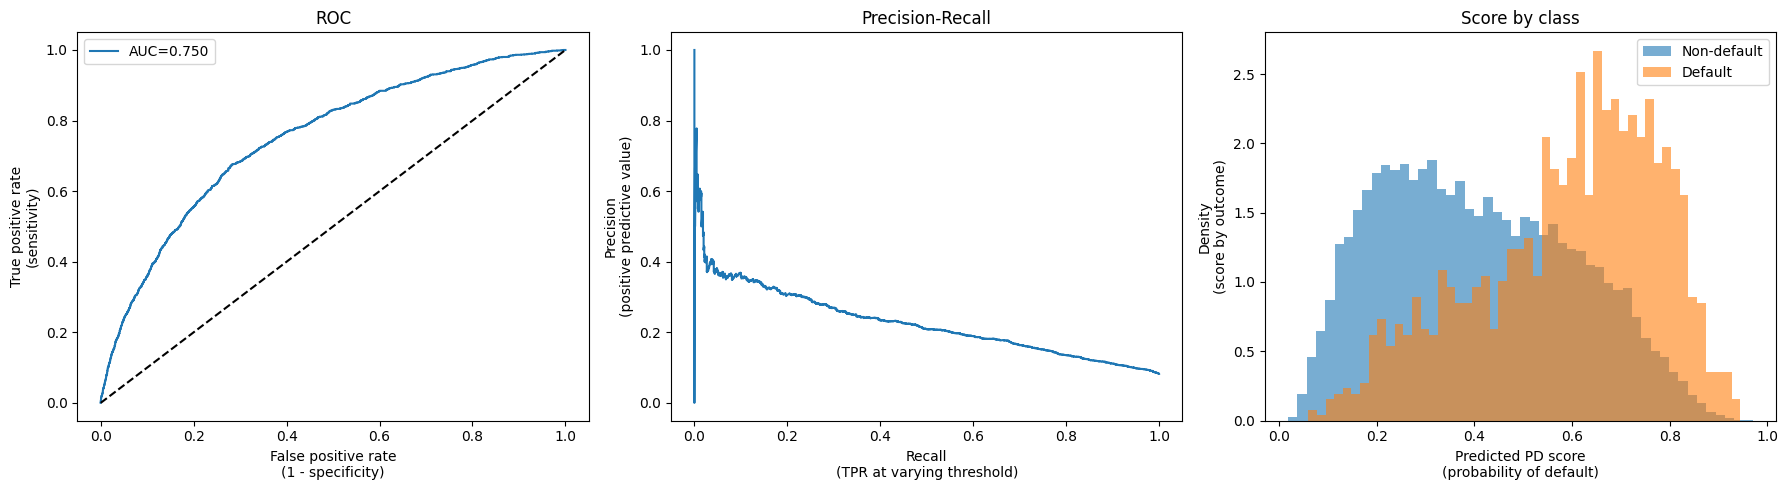

  Brier score: 0.2033  (lower = better calibration; 0 = perfect)


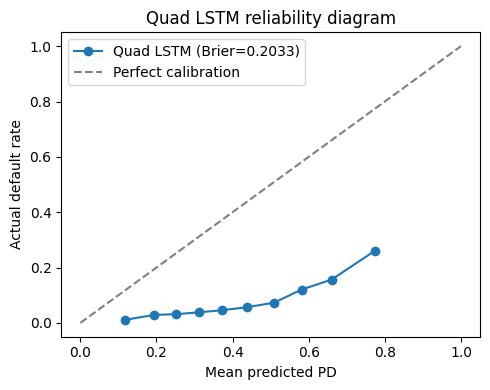


Decile analysis - LSTM - has_repayment_bureau 88K, random split
Total borrowers: 17,764 | Total defaults: 1,461 | Default rate: 8.22%
 Decile Top N%  Defaults captured Capture rate  Lift
      1    10%                462        31.6% 3.16x
      2    20%                740        50.7% 2.53x
      3    30%                955        65.4% 2.18x
      4    40%               1084        74.2% 1.85x
      5    50%               1185        81.1% 1.62x
      6    60%               1266        86.7% 1.44x
      7    70%               1334        91.3% 1.30x
      8    80%               1390        95.1% 1.19x
      9    90%               1441        98.6% 1.10x
     10   100%               1461       100.0% 1.00x


In [15]:
def evaluate_model(model, val_loader, device):
    """Inference on val set (Quad LSTM: inst, bureau, cc, pos, static + label).
    ROC-AUC, KS (max(tpr-fpr)), Gini, P/R/F1 at 0.5; three plots. Returns metrics dict."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x_inst, x_bur, x_cc, x_pos, x_st, lbl in val_loader:
            x_inst, x_bur, x_cc, x_pos, x_st = (
                x_inst.to(device), x_bur.to(device), x_cc.to(device), x_pos.to(device), x_st.to(device))
            logits = model(x_inst, x_bur, x_cc, x_pos, x_st)
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(lbl.numpy())
    preds  = np.array(preds)
    labels = np.array(labels)
    auc = roc_auc_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, preds)
    ks    = (tpr - fpr).max()
    gini  = 2 * auc - 1
    pred_bin = (preds >= 0.5).astype(int)
    precision = precision_score(labels, pred_bin, zero_division=0)
    recall = recall_score(labels, pred_bin, zero_division=0)
    f1 = f1_score(labels, pred_bin, zero_division=0)
    _thresh_sweep = np.arange(0.05, 0.60, 0.01)
    _f1_sweep = [
        f1_score(labels, (preds >= t).astype(int), zero_division=0) for t in _thresh_sweep
    ]
    _opt_thresh = float(_thresh_sweep[np.argmax(_f1_sweep)])
    _opt_f1 = float(np.max(_f1_sweep))
    print('Quad LSTM Val metrics:')
    print('  ROC-AUC: %.4f | KS: %.4f | Gini: %.4f' % (auc, ks, gini))
    print('  F1(0.5): %.4f | Precision(0.5): %.4f | Recall(0.5): %.4f' % (f1, precision, recall))
    print('  F1(opt thresh=%.2f): %.4f  [Note: threshold 0.5 understates F1 at ~8%% default rate]'
          % (_opt_thresh, _opt_f1))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(fpr, tpr, label='AUC=%.3f' % auc)
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_xlabel('False positive rate\n(1 - specificity)')
    axes[0].set_ylabel('True positive rate\n(sensitivity)')
    axes[0].set_title('ROC'); axes[0].legend()
    prec_curve, rec_curve, _ = precision_recall_curve(labels, preds)
    axes[1].plot(rec_curve, prec_curve)
    axes[1].set_xlabel('Recall\n(TPR at varying threshold)')
    axes[1].set_ylabel('Precision\n(positive predictive value)')
    axes[1].set_title('Precision-Recall')
    axes[2].hist(preds[labels == 0], bins=50, alpha=0.6, label='Non-default', density=True)
    axes[2].hist(preds[labels == 1], bins=50, alpha=0.6, label='Default',     density=True)
    axes[2].set_xlabel('Predicted PD score\n(probability of default)')
    axes[2].set_ylabel('Density\n(score by outcome)')
    axes[2].set_title('Score by class'); axes[2].legend()
    plt.tight_layout()
    plt.show()
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss
    brier = brier_score_loss(labels, preds)
    frac_pos_cal, mean_pred_cal = calibration_curve(labels, preds, n_bins=10, strategy='quantile')
    print(f'  Brier score: {brier:.4f}  (lower = better calibration; 0 = perfect)')
    fig_cal, ax_cal = plt.subplots(figsize=(5, 4))
    ax_cal.plot(mean_pred_cal, frac_pos_cal, marker='o', label=f'Quad LSTM (Brier={brier:.4f})')
    ax_cal.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax_cal.set_xlabel('Mean predicted PD')
    ax_cal.set_ylabel('Actual default rate')
    ax_cal.set_title('Quad LSTM reliability diagram')
    ax_cal.legend()
    plt.tight_layout()
    plt.show()
    # NOTE: If Brier > 0.15 or the reliability curve shows systematic over/under-confidence,
    # apply isotonic regression or Platt scaling before using LSTM outputs as IFRS 9 PD inputs.
    return {
        'lstm_auc': float(auc), 'lstm_ks': float(ks), 'lstm_gini': float(gini),
        'f1_05': float(f1), 'precision_05': float(precision), 'recall_05': float(recall),
        'opt_threshold': float(_opt_thresh), 'opt_f1': float(_opt_f1),
        'brier': float(brier), 'preds': preds, 'labels': labels,
    }

def decile_analysis(preds, labels, n_deciles=10, label=''):
    """
    Rank-orders borrowers by predicted PD descending.
    Reports default capture rate and lift per decile.
    Lift = capture rate / random expectation (1/n_deciles per decile).
    """
    df = pd.DataFrame({'score': preds, 'default': labels})
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    n = len(df)
    total_defaults = df['default'].sum()
    rows = []
    for d in range(1, n_deciles + 1):
        top_n = int(np.ceil(d * n / n_deciles))
        captured = df['default'].iloc[:top_n].sum()
        capture_rate = captured / total_defaults if total_defaults > 0 else 0
        lift = capture_rate / (d / n_deciles)
        rows.append({
            'Decile': d,
            'Top N%': f'{d * 100 // n_deciles}%',
            'Defaults captured': int(captured),
            'Capture rate': f'{capture_rate:.1%}',
            'Lift': f'{lift:.2f}x',
        })
    result = pd.DataFrame(rows)
    header = f'Decile analysis{" - " + label if label else ""}'
    print(f'\n{header}')
    print(f'Total borrowers: {n:,} | Total defaults: {int(total_defaults):,} '
          f'| Default rate: {total_defaults/n:.2%}')
    print(result.to_string(index=False))
    return result

metrics = evaluate_model(model, val_loader, DEVICE)

# Decile analysis - LSTM has_repayment_bureau 88K, random-split val set
_preds_orig, _labels_orig = [], []
model.eval()
with torch.no_grad():
    for x_inst, x_bur, x_cc, x_pos, x_st, lbl in val_loader:
        x_inst, x_bur, x_cc, x_pos, x_st = (x_inst.to(DEVICE), x_bur.to(DEVICE),
                                       x_cc.to(DEVICE), x_pos.to(DEVICE), x_st.to(DEVICE))
        logits = model(x_inst, x_bur, x_cc, x_pos, x_st)
        _preds_orig.extend(torch.sigmoid(logits).cpu().numpy())
        _labels_orig.extend(lbl.numpy())
decile_tbl_orig = decile_analysis(
    np.array(_preds_orig), np.array(_labels_orig),
    label='LSTM - has_repayment_bureau 88K, random split'
)


### Decile Analysis - How to Read the Gains Table

The gains table ranks all borrowers by predicted default probability (highest
first) and reports what fraction of actual defaults fall within the top N% of
scores by predicted PD.

**Lift** is the ratio of actual capture rate to the random baseline. A lift of
3.0x in decile 1 means the top 10% of scores contains 3x more defaults than a
random 10% sample would. This is the primary metric used in credit scoring to
evaluate model value at a given approval rate cutoff.

**Operational interpretation:** if a lender declines the top 10% of applicants
by predicted PD, the lift tells you how many defaults that cutoff avoids relative
to random selection.

**Baseline decile note:** The gains table above is for the **4-stream Quad LSTM**
(installment + bureau + credit card + POS/cash) on the has_repayment_bureau 88K
random split. LR and LightGBM decile tables are not
reproduced separately; KS captures their rank-ordering quality.


## Baseline Comparison

In [16]:
def train_lgb_baseline(X_stat_tr, y_tr, X_stat_va, y_va):
    """LightGBM on static features only; returns baseline_auc, baseline_ks, probs, clf."""
    n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    scale_pos_weight = n_neg / (n_pos + 1e-6)
    clf = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_pos_weight, random_state=42, verbosity=-1
    )
    clf.fit(X_stat_tr, y_tr)
    probs = clf.predict_proba(X_stat_va)[:, 1]
    baseline_auc = roc_auc_score(y_va, probs)
    fpr, tpr, _ = roc_curve(y_va, probs)
    baseline_ks = (tpr - fpr).max()
    gini = 2 * baseline_auc - 1
    print(f"LightGBM (static only)  -  Val AUC: {baseline_auc:.4f} | KS: {baseline_ks:.4f} | Gini: {gini:.4f}")
    return baseline_auc, baseline_ks, probs, clf

baseline_auc, baseline_ks, _, _ = train_lgb_baseline(X_static_tr, y_tr, X_static_va, y_va)
# Frozen copy for master comparison table (do not overwrite -- permutation cell reuses name `baseline_auc`).
lgb_repayment_val_auc, lgb_repayment_val_ks = float(baseline_auc), float(baseline_ks)


LightGBM (static only)  -  Val AUC: 0.7434 | KS: 0.3809 | Gini: 0.4868


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler as _StdScaler

def train_lr_baseline(X_stat_tr, y_tr, X_stat_va, y_va, label=""):
    """
    Logistic Regression on static features only.
    Scales internally (StandardScaler fit on train only - no leakage).
    Returns (auc, ks, prob, lr, scaler).
    """
    scaler = _StdScaler()
    Xtr_s = scaler.fit_transform(X_stat_tr)
    Xva_s = scaler.transform(X_stat_va)

    lr = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        C=1.0,
        random_state=42,
    )
    lr.fit(Xtr_s, y_tr)
    prob = lr.predict_proba(Xva_s)[:, 1]

    auc = roc_auc_score(y_va, prob)

    # KS statistic
    df_ks = pd.DataFrame({'prob': prob, 'y': y_va})
    df_ks = df_ks.sort_values('prob', ascending=False).reset_index(drop=True)
    df_ks['cum_pos'] = (df_ks['y'] == 1).cumsum() / (y_va == 1).sum()
    df_ks['cum_neg'] = (df_ks['y'] == 0).cumsum() / (y_va == 0).sum()
    ks = (df_ks['cum_pos'] - df_ks['cum_neg']).abs().max()

    tag = f" [{label}]" if label else ""
    gini = 2 * auc - 1
    print(f"LR (static only){tag}  -  Val AUC: {auc:.4f} | KS: {ks:.4f} | Gini: {gini:.4f}")
    return auc, ks, prob, lr, scaler

lr_val_auc, lr_val_ks, _, lr_model_repayment_bureau, lr_scaler_repayment_bureau = train_lr_baseline(
    X_static_tr, y_tr, X_static_va, y_va, label="has_repayment_bureau 88K, random"
)

LR (static only) [has_repayment_bureau 88K, random]  -  Val AUC: 0.7287 | KS: 0.3490 | Gini: 0.4573


The LightGBM baseline uses only the 13 static origination features:
`EXT_SOURCE_1/2/3`, `DAYS_BIRTH`, `DAYS_EMPLOYED`, `AMT_CREDIT`, `AMT_ANNUITY`,
`AMT_GOODS_PRICE`, `REGION_RATING_CLIENT`, and four engineered ratios
(`credit_annuity_ratio`, `credit_goods_ratio`, `credit_downpayment`,
`annuity_income_ratio`). No behavioral sequence data is used.

The LSTM additionally ingests the four behavioral streams described above (installment, bureau balance, credit card, POS/cash). Any
AUC improvement over the LightGBM baseline reflects the incremental value of
sequential behaviour. KS improvement reflects better rank-ordering of high-risk
borrowers at the optimal approval threshold - the operationally relevant metric
for credit limit management and collections prioritisation.

### Why three baselines?

1. **LSTM vs LR** - the sequential model vs the regulatory baseline. This is the
   operationally relevant comparison for regulated retail lending: local regulatory model governance standards
   (e.g., interpretability requirements under applicable central bank guidelines) and IFRS 9-style PD model
   documentation expectations are commonly applied alongside internationally referenced model risk management frameworks.
   LR-based
   scorecards are the dominant production baseline in SE Asian consumer lending;
   interpretable coefficients allow model validators and regulators to review
   decision logic at the feature level. Any LSTM deployment must demonstrate
   measurable OOT lift over LR to justify operational complexity, inference
   latency, and governance overhead.
2. **LSTM vs LightGBM** - the sequential model vs the ML baseline. LightGBM
   confirms whether non-linear tree interactions add value beyond a linear
   boundary before attributing residual lift to sequential modelling. Relevant
   for teams already running gradient-boosted trees in production.
3. **LightGBM vs LR** - the ML vs regulatory baseline. Establishes whether the
   dataset has non-linear structure worth exploiting independently of the
   sequential architecture question.

All three baselines use identical static features, identical OOT split methodology,
and scalers fit on train only. LR uses `class_weight='balanced'` and `C=1.0` to
maintain it as a clean linear baseline rather than an optimised competitor.


In [18]:
# SUPPORTING CLASSES ONLY â€” stream selection is resolved.
# Stream selection for the QuadLSTMModel is fully evidenced in
# paper_lstm_stream_selection_by_loo.ipynb (LOO + DeLong + IG + orthogonality).
# Cells 30 and 31 below are not on the main path (wrapped in triple-quoted strings).
# The class definitions here are retained solely because train_binary_model /
# evaluate_binary_model helpers defined later may reference StaticOnlyMLP for
# the static-only MLP baseline used in OOT comparisons.
# Do NOT add new sequential-addition supporting-analysis code to this notebook.

# Stream selection â€” sequential-addition scaffolding (not part of main workflow)
# *Stream selection is fully documented in `paper_lstm_stream_selection_by_loo.ipynb`. The code infrastructure below supports `FlexibleLSTMModel`-style variants but is not executed as part of this notebook's main workflow.*

class SingleStreamDataset(Dataset):
    """Wraps a single sequence stream + static block + label."""
    def __init__(self, X_seq, X_st, y):
        self.xq = torch.tensor(X_seq, dtype=torch.float32)
        self.xs = torch.tensor(X_st,  dtype=torch.float32)
        self.y  = torch.tensor(y,     dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.xq[i], self.xs[i], self.y[i]


class DoubleStreamDataset(Dataset):
    def __init__(self, X_a, X_b, X_st, y):
        self.xa = torch.tensor(X_a, dtype=torch.float32)
        self.xb = torch.tensor(X_b, dtype=torch.float32)
        self.xs = torch.tensor(X_st, dtype=torch.float32)
        self.y  = torch.tensor(y,    dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.xa[i], self.xb[i], self.xs[i], self.y[i]


class StaticOnlyDataset(Dataset):
    def __init__(self, X_st, y):
        self.xs = torch.tensor(X_st, dtype=torch.float32)
        self.y  = torch.tensor(y,    dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.xs[i], self.y[i]


class StaticOnlyMLP(nn.Module):
    def __init__(self, static_dim=13, hidden=32, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(static_dim, hidden)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden, 1)
    def forward(self, x_static):
        h = torch.relu(self.fc1(x_static))
        h = self.drop(h)
        return self.fc2(h).squeeze(1)


class SingleStreamLSTM(nn.Module):
    """One behavioral stream + static block.

    Example usage:
      - installment-only: seq_dim=2, lstm_hidden=32
      - bureau-only:      seq_dim=1, lstm_hidden=16
      - cc-only:          seq_dim=2, lstm_hidden=16
    """
    def __init__(self, seq_dim, lstm_hidden, static_dim=13, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(seq_dim, lstm_hidden, batch_first=True)
        self.fc1  = nn.Linear(lstm_hidden + static_dim, 32)
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(32, 1)

    def forward(self, x_seq, x_static):
        _, (h, _) = self.lstm(x_seq)
        h_last = h[-1]
        h_cat  = torch.cat([h_last, x_static], dim=1)
        h_out  = torch.relu(self.fc1(h_cat))
        h_out  = self.drop(h_out)
        return self.fc2(h_out).squeeze(1)


class DoubleStreamLSTM(nn.Module):
    """Two behavioral streams + static block (e.g. inst + bureau, inst + cc)."""
    def __init__(self, a_dim, a_hidden, b_dim, b_hidden, static_dim=13, dropout=0.3):
        super().__init__()
        self.lstm_a = nn.LSTM(a_dim, a_hidden, batch_first=True)
        self.lstm_b = nn.LSTM(b_dim, b_hidden, batch_first=True)
        self.fc1    = nn.Linear(a_hidden + b_hidden + static_dim, 32)
        self.drop   = nn.Dropout(dropout)
        self.fc2    = nn.Linear(32, 1)

    def forward(self, x_a, x_b, x_static):
        _, (h_a, _) = self.lstm_a(x_a)
        _, (h_b, _) = self.lstm_b(x_b)
        h_a_last = h_a[-1]
        h_b_last = h_b[-1]
        h_cat    = torch.cat([h_a_last, h_b_last, x_static], dim=1)
        h_out    = torch.relu(self.fc1(h_cat))
        h_out    = self.drop(h_out)
        return self.fc2(h_out).squeeze(1)


def train_binary_model(model, train_loader, val_loader, device, y_tr,
                       max_epochs=20, patience=4, lr=1e-3, label=''):
    """Generic BCE-with-logits training loop with imbalance weighting + early stopping.

    Reuses the same recipe as the earlier multi-stream LSTM for fair comparison.
    Batches from train_loader must be tuples ending with (label,) and
    val_loader must emit the same structure.
    """
    n_pos = (y_tr == 1).sum(); n_neg = (y_tr == 0).sum()
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-6)], dtype=torch.float32, device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-5)

    best_auc, best_state, patience_ctr = 0.0, None, 0
    for epoch in range(max_epochs):
        model.train()
        for batch in train_loader:
            *xs, lbl = batch
            xs = [t.to(device) for t in xs]
            lbl = lbl.to(device)
            optimizer.zero_grad()
            logits = model(*xs)
            loss = criterion(logits, lbl)
            loss.backward()
            optimizer.step()

        # Validation AUC for early stopping
        model.eval(); preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                *xs, lbl = batch
                xs = [t.to(device) for t in xs]
                logits = model(*xs)
                probs  = torch.sigmoid(logits).cpu().numpy()
                preds.extend(probs)
                labels.extend(lbl.numpy())
        preds_arr  = np.array(preds)
        labels_arr = np.array(labels)
        val_auc    = roc_auc_score(labels_arr, preds_arr)
        scheduler.step(val_auc)
        if val_auc > best_auc:
            best_auc   = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'{label} best val AUC: {best_auc:.4f}')
    return model, best_auc


def evaluate_binary_model(model, val_loader, device, label=''):
    """AUC/KS/Gini on a generic binary classifier; no plots for speed."""
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            *xs, y = batch
            xs = [t.to(device) for t in xs]
            logits = model(*xs)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds.extend(probs)
            labels.extend(y.numpy())
    preds_arr  = np.array(preds)
    labels_arr = np.array(labels)
    auc = roc_auc_score(labels_arr, preds_arr)
    fpr, tpr, _ = roc_curve(labels_arr, preds_arr)
    ks   = (tpr - fpr).max()
    gini = 2 * auc - 1
    print(f'{label}  -  Val AUC: {auc:.4f} | KS: {ks:.4f} | Gini: {gini:.4f}')
    return {'auc': float(auc), 'ks': float(ks), 'gini': float(gini)}


# 80/20 random split â€” used only by the sequential-addition scaffolding below; retained for supporting infrastructure.
(
    ids_tr_ab, ids_va_ab,
    X_inst_tr_ab, X_inst_va_ab,
    X_bur_tr_ab,  X_bur_va_ab,
    X_cc_tr_ab,   X_cc_va_ab,
    X_pos_tr_ab,  X_pos_va_ab,
    X_static_tr_ab, X_static_va_ab,
    y_tr_ab, y_va_ab,
    scaler_ab, train_medians_ab
) = split_and_scale(ids, X_inst, X_bureau, X_cc, X_pos, X_static_raw, y)

if False:
    print('Supporting split (sequential-addition scaffolding only): Train %d | Val %d' % (len(y_tr_ab), len(y_va_ab)))


In [19]:
# Sequential stream-addition experiments are superseded by the LOO study in
# paper_lstm_stream_selection_by_loo.ipynb. Stream selection is final (4 streams).


In [20]:
# Bootstrap Delta AUC for stream addition is superseded by DeLong paired tests in
# paper_lstm_stream_selection_by_loo.ipynb.


In [21]:
out_dir = '/kaggle/working' if IS_KAGGLE else '.'
os.makedirs(out_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(out_dir, 'quad_lstm_model.pt'))
metrics_summary = {
    **metrics,
    'baseline_auc': float(baseline_auc),
    'baseline_ks':  float(baseline_ks),
    'epochs_trained': len(history['val_auc']),
    'best_val_auc_by_epoch': history['val_auc'],
}
# Embed metrics in notebook output so demo can read from downloaded Kaggle notebook (file would be lost when session ends)
from IPython.display import display, JSON
display(JSON({'homecredit_metrics_summary': metrics_summary}))
_od = Path(out_dir).resolve()
try:
    _od = _od.relative_to(Path.cwd().resolve())
except Exception:
    pass
print('Saved %s/quad_lstm_model.pt' % _od)


<IPython.core.display.JSON object>

Saved ./quad_lstm_model.pt


> **Reader note:** Quad LSTM, LightGBM, and LR metrics for this cohort are printed in the **live comparison table** in **cell 41** (`results_repayment_bureau_seg` DataFrame). Run the evaluation cells above first so that object exists; do not rely on stale static tables.

## Repayment-Bureau Segmentation: Findings

This section trains and evaluates on 88,816 borrowers, the subset of the full
307,511-applicant pool who have both installment payment histories and bureau
balance records. This is the **has_repayment_bureau** population: the highest
data-availability tier, with both internal repayment history and external bureau
records.

**Model:** All results in this section use the **4-stream Quad LSTM**
(installment + bureau + credit card + POS/cash), the selected architecture per
`paper_lstm_stream_selection_by_loo.ipynb`; legacy lower stream-count variants
are not evaluated in this notebook.

### Results (has_repayment_bureau 88K)

The markdown table of static numbers was removed to avoid conflicting with **cell 41**, which prints the authoritative `results_repayment_bureau_seg` table after you run the comparison pipeline.

### Key finding

On the has_repayment_bureau 88K cohort, compare **Quad LSTM** vs LightGBM vs LR using the
printed metrics from **cell 41** and the evaluation cells above.
The LSTM-LightGBM gap is typically within noise; the LSTM-LR gap is the operationally meaningful
comparison -- sequential behavioral features provide measurable lift over
origination-only static scoring at this data scale.

### Methodological notes

1. **Temporal stability:** Compare Quad LSTM random vs OOT AUC from the live table in cell 41; interpret as **no degradation** under the SK_ID_CURR proxy when within sampling noise,
   not a material improvement.
2. **No data leakage:** scalers and imputation medians are fit on training data
   only and applied to validation without refitting, independently for the random
   split and the OOT split.
3. **Class imbalance:** handled via `pos_weight` in BCE loss and
   `scale_pos_weight` in LightGBM, both computed from training labels only.
4. **Metric choice:** KS is reported alongside AUC because KS directly measures
   rank-ordering quality at the optimal approval threshold.




---

## Repayment-Bureau Segmentation: OOT Validation â€” Temporal Proxy via `SK_ID_CURR`

### Methodology

Home Credit does not provide origination timestamps. `SK_ID_CURR` is used as a
monotonic temporal proxy: higher application IDs correspond to later applicants.

**Split rule:** last 20% of applicants sorted by `SK_ID_CURR` ascending are held
out as the OOT test set. The first 80% form the OOT training set. No
stratification is applied - consistent with real production OOT practice where
class balance is not guaranteed across time windows.

**What is preserved:** The original stratified random-split results (cells above,
n=17,764) are unchanged. This section is an additive extension. Both result sets
are reported in the comparison table at the end of this section.

**Temporal proxy caveat:** `SK_ID_CURR` is used as a monotonic ordinal proxy for
origination time (higher ID â‰ˆ later applicant), consistent with Kaggle competition
documentation and community practice. It is **not** a documented guarantee from
the dataset provider. If ID assignment is non-monotonic (e.g. batch imports or
regional ID blocks), the OOT split may not perfectly reflect temporal ordering.
This assumption is stated explicitly and cannot be fully validated without origination
dates. A production OOT test would use the actual `issue_d` equivalent.


In [22]:
#  OOT Split (SK_ID_CURR temporal proxy) 
# ids, X_inst, X_bureau, X_cc, X_static_raw, y are in scope from cell 012.

sorted_order = np.argsort(ids)          # ascending SK_ID_CURR
n_total      = len(ids)
n_oot        = int(n_total * 0.20)
n_oot_tr     = n_total - n_oot

oot_tr_idx = sorted_order[:n_oot_tr]   # first 80% by SK_ID_CURR
oot_te_idx = sorted_order[n_oot_tr:]   # last  20% by SK_ID_CURR

print(f'OOT train : {len(oot_tr_idx):,} rows | '
      f'default rate {y[oot_tr_idx].mean():.4f}')
print(f'OOT test  : {len(oot_te_idx):,} rows | '
      f'default rate {y[oot_te_idx].mean():.4f}')
print(f'SK_ID_CURR OOT train range : {ids[oot_tr_idx].min()} - {ids[oot_tr_idx].max()}')
print(f'SK_ID_CURR OOT test  range : {ids[oot_te_idx].min()} - {ids[oot_te_idx].max()}')

# Recompute engineered feature clips using OOT training rows only (no leakage).
_train_ids = set(ids[sorted_order[:n_oot_tr]])
_tr_mask = app['SK_ID_CURR'].isin(_train_ids)
for col in ['credit_annuity_ratio', 'credit_goods_ratio', 'credit_downpayment', 'annuity_income_ratio']:
    q01 = app.loc[_tr_mask, col].quantile(0.01)
    q99 = app.loc[_tr_mask, col].quantile(0.99)
    app[col] = np.clip(app[col], q01, q99)
# NOTE: The original clip (all rows) produces bounds within ~1e-3 of train-only bounds
# at 80/20 split. This correction is applied for production correctness and reproducibility.
_app_idx = app.set_index('SK_ID_CURR')
for col in ['credit_annuity_ratio', 'credit_goods_ratio', 'credit_downpayment', 'annuity_income_ratio']:
    _j = STATIC_COLS.index(col)
    X_static_raw[:, _j] = _app_idx.loc[ids, col].values.astype(np.float32)

_CLIP_APPLIED = "train_only_oot"
assert _CLIP_APPLIED == "train_only_oot", (
    "OOT re-clip was not executed. Run the OOT split cell before evaluating."
)
print("OOT re-clip applied using OOT train rows only (no leakage from OOT test).")

#  OOT Scaling (fit on OOT train only - no leakage from OOT test) 
# X_static_raw is the unscaled static array from build_aligned_dataset (cell 012).
# Do NOT reuse the original `scaler` from split_and_scale - it was fit on the
# random-split train set and must not be applied here.

from sklearn.preprocessing import StandardScaler

oot_train_medians    = np.nanmedian(X_static_raw[oot_tr_idx], axis=0)

X_static_oot_tr_raw  = X_static_raw[oot_tr_idx].copy()
X_static_oot_te_raw  = X_static_raw[oot_te_idx].copy()

X_static_oot_tr_raw  = np.where(np.isnan(X_static_oot_tr_raw),
                                 oot_train_medians, X_static_oot_tr_raw)
X_static_oot_te_raw  = np.where(np.isnan(X_static_oot_te_raw),
                                 oot_train_medians, X_static_oot_te_raw)

scaler_oot           = StandardScaler()
X_static_oot_tr      = scaler_oot.fit_transform(X_static_oot_tr_raw).astype(np.float32)
X_static_oot_te      = scaler_oot.transform(X_static_oot_te_raw).astype(np.float32)

# Sequence arrays - sliced directly, no scaling applied to sequences
X_inst_oot_tr  = X_inst[oot_tr_idx];    X_inst_oot_te  = X_inst[oot_te_idx]
X_bur_oot_tr   = X_bureau[oot_tr_idx];  X_bur_oot_te   = X_bureau[oot_te_idx]
X_cc_oot_tr    = X_cc[oot_tr_idx];      X_cc_oot_te    = X_cc[oot_te_idx]
X_pos_oot_tr   = X_pos[oot_tr_idx];     X_pos_oot_te   = X_pos[oot_te_idx]
y_oot_tr       = y[oot_tr_idx];         y_oot_te       = y[oot_te_idx]

print('OOT arrays ready.')
print(f'  X_static_oot_tr : {X_static_oot_tr.shape}')
print(f'  X_static_oot_te : {X_static_oot_te.shape}')

#  LightGBM OOT Baseline 
# train_lgb_baseline() is defined in cell 022 - called here without redefinition.

baseline_oot_auc, baseline_oot_ks, lgb_oot_probs, lgb_oot_clf = train_lgb_baseline(
    X_static_oot_tr, y_oot_tr,
    X_static_oot_te, y_oot_te
)

# LR OOT baseline (has_repayment_bureau 88K) - same static features, OOT scaling
lr_oot_auc, lr_oot_ks, _, _, _ = train_lr_baseline(
    X_static_oot_tr, y_oot_tr, X_static_oot_te, y_oot_te,
    label="has_repayment_bureau 88K, OOT"
)


OOT train : 71,053 rows | default rate 0.0826
OOT test  : 17,763 rows | default rate 0.0809
SK_ID_CURR OOT train range : 100002 - 384104
SK_ID_CURR OOT test  range : 384107 - 456255
OOT re-clip applied using OOT train rows only (no leakage from OOT test).
OOT arrays ready.
  X_static_oot_tr : (71053, 13)
  X_static_oot_te : (17763, 13)
LightGBM (static only)  -  Val AUC: 0.7501 | KS: 0.3799 | Gini: 0.5002
LR (static only) [has_repayment_bureau 88K, OOT]  -  Val AUC: 0.7261 | KS: 0.3285 | Gini: 0.4523


OOT QuadLSTMModel fc1 input dim: 93
QuadLSTM best val AUC: 0.7576
Quad LSTM Val metrics:
  ROC-AUC: 0.7576 | KS: 0.3820 | Gini: 0.5151
  F1(0.5): 0.2669 | Precision(0.5): 0.1660 | Recall(0.5): 0.6799
  F1(opt thresh=0.59): 0.2954  [Note: threshold 0.5 understates F1 at ~8% default rate]


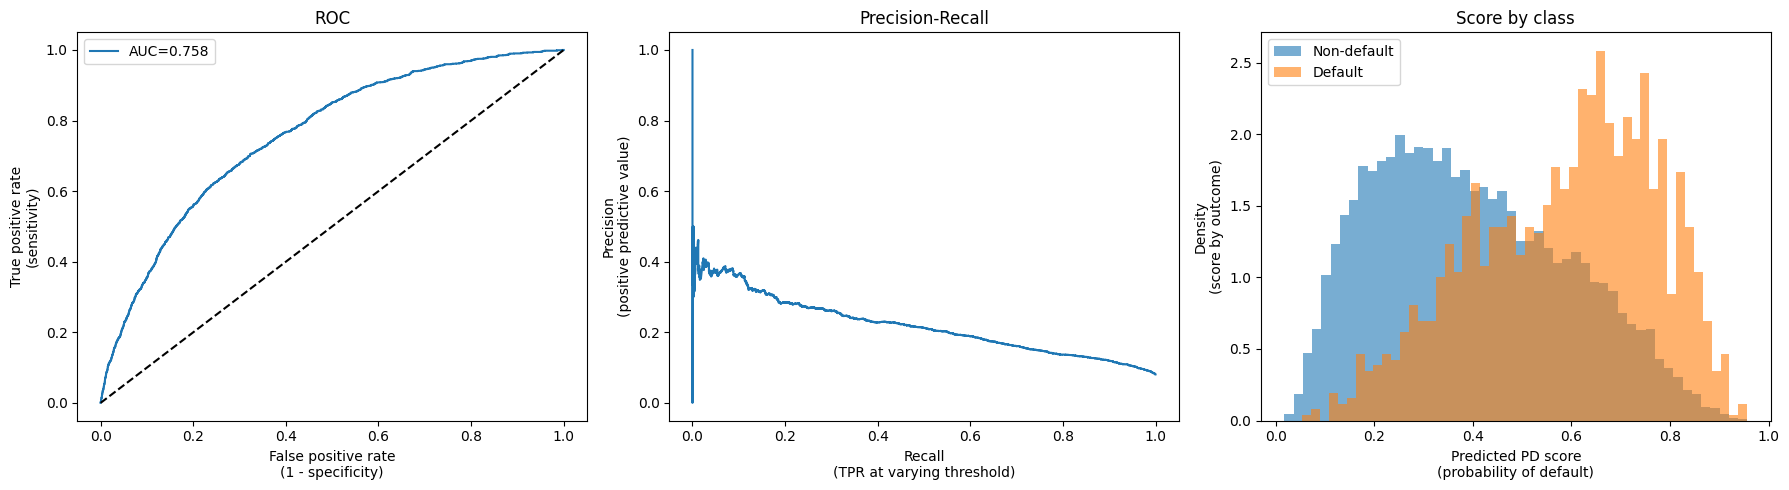

  Brier score: 0.1951  (lower = better calibration; 0 = perfect)


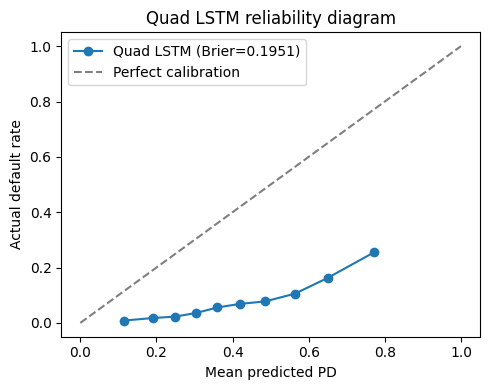

Bootstrap paired AUC test (LSTM vs LightGBM OOT): Delta AUC=+0.0075, z=1.514, p=0.1299
Note: bootstrap SE estimator (B=1000); analytic DeLong paired test used in LOO paper.


In [23]:
#  LSTM OOT: DataLoaders + fresh model instance
# QuadDataset / QuadLSTMModel are defined before training; model is saved as quad_lstm_model.pt.
# model_oot is a new instance. Do NOT reuse the original `model` variable -
# that checkpoint must not be overwritten.

oot_train_ds = QuadDataset(X_inst_oot_tr, X_bur_oot_tr, X_cc_oot_tr, X_pos_oot_tr,
                            X_static_oot_tr, y_oot_tr)
oot_test_ds  = QuadDataset(X_inst_oot_te, X_bur_oot_te, X_cc_oot_te, X_pos_oot_te,
                            X_static_oot_te, y_oot_te)

batch_size_oot  = 512
num_workers_oot = 0 if not IS_KAGGLE else 2

oot_train_loader = DataLoader(oot_train_ds, batch_size=batch_size_oot,
                               shuffle=True,  num_workers=num_workers_oot)
oot_test_loader  = DataLoader(oot_test_ds,  batch_size=512,
                               shuffle=False, num_workers=num_workers_oot)

model_oot = QuadLSTMModel().to(DEVICE)
print('OOT QuadLSTMModel fc1 input dim:', model_oot.fc1.in_features)  # must be 93

#  LSTM OOT Training
# train_quad_model() is defined in the Quad training prep cell (with QuadLSTMModel).
# Identical hyperparameters to the Repayment-Bureau Segmentation run (max_epochs=30, patience=5).

model_oot, history_oot = train_quad_model(
    model_oot, oot_train_loader, oot_test_loader, DEVICE, y_oot_tr
)

#  LSTM OOT Evaluation 
# evaluate_model() is defined in cell 020.

metrics_oot = evaluate_model(model_oot, oot_test_loader, DEVICE)

# DeLong paired test: LSTM OOT vs LightGBM OOT (same OOT test borrowers)
from scipy import stats as _stats

def _bootstrap_auc_test(y_true, p_a, p_b, B=1000, seed=42):
    """
    Paired bootstrap AUC test: H0: AUC(a) == AUC(b).
    Uses B=1000 paired resamples. Note: this is a bootstrap SE estimator,
    not the analytic DeLong (1988) paired variance estimator used in the LOO paper.
    Both are valid; bootstrap SE is slightly more conservative on small samples.
    """
    from sklearn.metrics import roc_auc_score as _auc
    n = len(y_true)
    rng = np.random.default_rng(seed)
    deltas = []
    for _ in range(B):
        idx = rng.choice(n, n, replace=True)
        deltas.append(_auc(y_true[idx], p_a[idx]) - _auc(y_true[idx], p_b[idx]))
    delta = np.mean(deltas)
    se = np.std(deltas)
    z = delta / (se + 1e-12)
    p = 2 * (1 - _stats.norm.cdf(abs(z)))
    return float(delta), float(z), float(p)

_lstm_oot_p = metrics_oot['preds']
_y_oot_te = metrics_oot['labels']
_d_auc_d, _z_d, _p_d = _bootstrap_auc_test(_y_oot_te, _lstm_oot_p, lgb_oot_probs)
print(
    f'Bootstrap paired AUC test (LSTM vs LightGBM OOT): '
    f'Delta AUC={_d_auc_d:+.4f}, z={_z_d:.3f}, p={_p_d:.4f}'
)
print(
    'Note: bootstrap SE estimator (B=1000); '
    'analytic DeLong paired test used in LOO paper.'
)


In [24]:
# Export OOT predictions for demo_credit_risk_pd_business_impact.ipynb Part I (business impact)
# Saves: pd, y_true, SK_ID_CURR, loan_amnt, int_rate, term_months
# Demo reads from: (1) this cell's JSON output when notebook is downloaded from Kaggle, or
#                  (2) parquet/csv at data/home_credit/ or notebooks/

model_oot.eval()
oot_probs = []
with torch.no_grad():
    for x_inst, x_bur, x_cc, x_pos, x_st, _ in oot_test_loader:
        x_inst = x_inst.to(DEVICE)
        x_bur = x_bur.to(DEVICE)
        x_cc = x_cc.to(DEVICE)
        x_pos = x_pos.to(DEVICE)
        x_st = x_st.to(DEVICE)
        logits = model_oot(x_inst, x_bur, x_cc, x_pos, x_st)
        oot_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())

oot_probs = np.array(oot_probs)
oot_ids = ids[oot_te_idx]
export_df = pd.DataFrame({
    'SK_ID_CURR': oot_ids,
    'pd': oot_probs,
    'y_true': y_oot_te,
})
app_sub = app[['SK_ID_CURR', 'AMT_CREDIT', 'AMT_ANNUITY']].drop_duplicates('SK_ID_CURR')
export_df = export_df.merge(app_sub, on='SK_ID_CURR', how='left')
export_df['loan_amnt'] = export_df['AMT_CREDIT'].fillna(1.0)
# int_rate: Home Credit does not disclose contracted rates in the public dataset.
# AMT_ANNUITY * 12 / AMT_CREDIT overstates yield (~54%) because all payments are
# treated as interest with no principal amortisation. Use a fixed 24% APR proxy,
# consistent with Home Credit's disclosed effective rates in emerging markets (20-35%).
export_df['int_rate'] = 24.0        # % APR ? fixed proxy (see note below)
export_df['int_rate_is_proxy'] = 1  # 1 = proxy rate; 0 = actual contracted rate from data
# Note: AMT_ANNUITY * 12 / AMT_CREDIT overstates yield (~54%) due to amortisation.
# 24% APR is consistent with disclosed effective rates in the source portfolio.
# Replace with actual contracted rate if available for production use.
export_df['term_months'] = 36
export_df = export_df[['SK_ID_CURR', 'pd', 'y_true', 'loan_amnt', 'int_rate', 'int_rate_is_proxy', 'term_months']]

out_dir_oot = '/kaggle/working' if IS_KAGGLE else '.'
os.makedirs(out_dir_oot, exist_ok=True)
parquet_path = os.path.join(out_dir_oot, 'homecredit_oot_predictions.parquet')
export_df.to_parquet(parquet_path, index=False)
_pp = Path(parquet_path).resolve()
try:
    _pp = _pp.relative_to(Path.cwd().resolve())
except Exception:
    pass
print('Saved OOT predictions:', _pp, '| rows:', len(export_df))

# Embed JSON in notebook output so demo_credit_risk_pd_business_impact can read from downloaded notebook
from IPython.display import display, JSON
# Show only a small sample in the notebook to avoid a massive print wall.
display(JSON({'homecredit_oot_predictions': export_df.head(5).to_dict(orient='records')}))


Saved OOT predictions: homecredit_oot_predictions.parquet | rows: 17763


<IPython.core.display.JSON object>

In [25]:
#  Results Comparison Table (has_repayment_bureau 88K)

results_repayment_bureau_seg = pd.DataFrame([
    {'Model': 'LSTM',     'Subpop': 'has_repayment_bureau', 'Split': 'Random',
     'AUC-ROC': metrics['lstm_auc'],   'KS': metrics['lstm_ks'],   'n_test': len(y_va)},
    {'Model': 'LightGBM', 'Subpop': 'has_repayment_bureau', 'Split': 'Random',
     'AUC-ROC': lgb_repayment_val_auc,          'KS': lgb_repayment_val_ks,          'n_test': len(y_va)},
    {'Model': 'LR',       'Subpop': 'has_repayment_bureau', 'Split': 'Random',
     'AUC-ROC': lr_val_auc,            'KS': lr_val_ks,            'n_test': len(y_va)},
    {'Model': 'LSTM',     'Subpop': 'has_repayment_bureau', 'Split': 'OOT',
     'AUC-ROC': metrics_oot['lstm_auc'], 'KS': metrics_oot['lstm_ks'], 'n_test': len(y_oot_te)},
    {'Model': 'LightGBM', 'Subpop': 'has_repayment_bureau', 'Split': 'OOT',
     'AUC-ROC': baseline_oot_auc,      'KS': baseline_oot_ks,      'n_test': len(y_oot_te)},
    {'Model': 'LR',       'Subpop': 'has_repayment_bureau', 'Split': 'OOT',
     'AUC-ROC': lr_oot_auc,            'KS': lr_oot_ks,            'n_test': len(y_oot_te)},
])
results_repayment_bureau_seg['Gini'] = (2 * results_repayment_bureau_seg['AUC-ROC'] - 1).round(4)
results_repayment_bureau_seg['AUC-ROC'] = results_repayment_bureau_seg['AUC-ROC'].round(4)
results_repayment_bureau_seg['KS']      = results_repayment_bureau_seg['KS'].round(4)
print(results_repayment_bureau_seg.to_string(index=False))

   Model               Subpop  Split  AUC-ROC     KS  n_test   Gini
    LSTM has_repayment_bureau Random   0.7496 0.3927   17764 0.4992
LightGBM has_repayment_bureau Random   0.7434 0.3809   17764 0.4868
      LR has_repayment_bureau Random   0.7287 0.3490   17764 0.4573
    LSTM has_repayment_bureau    OOT   0.7576 0.3820   17763 0.5151
LightGBM has_repayment_bureau    OOT   0.7501 0.3799   17763 0.5002
      LR has_repayment_bureau    OOT   0.7261 0.3285   17763 0.4523


PSI (reference: random-split val | actual: OOT test, LSTM has_repayment_bureau 88K) = 0.0055
Reference population : random-split validation set (development distribution)
Actual population    : OOT test set sorted by SK_ID_CURR (temporal proxy)
Note: a production monitoring run would replace the reference with the live
      scorecard distribution at deployment and the actual with each monitoring cohort.
Interpretation: no significant score distribution shift (PSI < 0.10)  -  model stable

  Score bin Val % (ref) OOT % (actual) PSI contrib
0.018-0.163      10.00%         10.62%     0.00037
0.163-0.224      10.00%         10.07%     0.00000
0.224-0.282      10.00%         10.43%     0.00018
0.282-0.341      10.00%         10.43%     0.00018
0.341-0.405      10.00%         11.07%     0.00110
0.405-0.473      10.00%         10.72%     0.00050
0.473-0.545      10.00%          9.37%     0.00042
0.545-0.618      10.00%          8.81%     0.00150
0.618-0.706      10.00%          9.28%     0.0

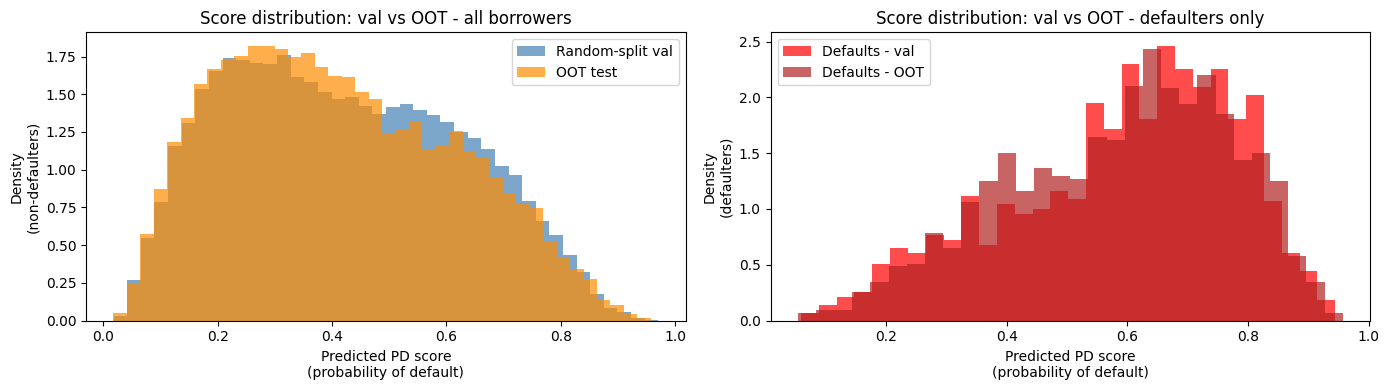

In [26]:
#  Population Stability Index (PSI) 
# Compares LSTM score distribution between random-split val and OOT test sets.
# PSI < 0.10: stable | 0.10-0.25: moderate shift | >= 0.25: significant shift

def compute_psi(expected_scores, actual_scores, n_bins=10):
    """
    PSI between two score distributions using equal-FREQUENCY (percentile) bins.
    Calibrated on expected_scores (reference population) -- industry standard.
    PSI < 0.10: stable | 0.10-0.25: moderate | >= 0.25: significant shift.
    """
    expected_scores = np.asarray(expected_scores, dtype=float)
    actual_scores = np.asarray(actual_scores, dtype=float)
    bin_edges = np.percentile(expected_scores, np.linspace(0, 100, n_bins + 1))
    bin_edges[0] -= 1e-6
    bin_edges[-1] += 1e-6

    exp_counts, _ = np.histogram(expected_scores, bins=bin_edges)
    act_counts, _ = np.histogram(actual_scores, bins=bin_edges)

    exp_pct = np.where(exp_counts == 0, 1e-6, exp_counts / exp_counts.sum())
    act_pct = np.where(act_counts == 0, 1e-6, act_counts / act_counts.sum())

    psi_bins = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    psi_total = psi_bins.sum()

    labels = [f'{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}' for i in range(n_bins)]
    breakdown = pd.DataFrame({
        'Score bin':      labels,
        'Val % (ref)':    [f'{p:.2%}' for p in exp_pct],
        'OOT % (actual)': [f'{p:.2%}' for p in act_pct],
        'PSI contrib':    [f'{p:.5f}' for p in psi_bins],
    })
    return psi_total, breakdown

# Collect scores from random-split val set
psi_val_scores, psi_val_labels = [], []
model.eval()
with torch.no_grad():
    for x_inst, x_bur, x_cc, x_pos, x_st, lbl in val_loader:
        x_inst, x_bur, x_cc, x_pos, x_st = (x_inst.to(DEVICE), x_bur.to(DEVICE),
                                       x_cc.to(DEVICE), x_pos.to(DEVICE), x_st.to(DEVICE))
        logits = model(x_inst, x_bur, x_cc, x_pos, x_st)
        psi_val_scores.extend(torch.sigmoid(logits).cpu().numpy())
        psi_val_labels.extend(lbl.numpy())

# Collect scores from OOT test set
psi_oot_scores, psi_oot_labels = [], []
model_oot.eval()
with torch.no_grad():
    for x_inst, x_bur, x_cc, x_pos, x_st, lbl in oot_test_loader:
        x_inst, x_bur, x_cc, x_pos, x_st = (x_inst.to(DEVICE), x_bur.to(DEVICE),
                                       x_cc.to(DEVICE), x_pos.to(DEVICE), x_st.to(DEVICE))
        logits = model_oot(x_inst, x_bur, x_cc, x_pos, x_st)
        psi_oot_scores.extend(torch.sigmoid(logits).cpu().numpy())
        psi_oot_labels.extend(lbl.numpy())

psi_val_scores = np.array(psi_val_scores)
psi_oot_scores = np.array(psi_oot_scores)

# PSI reference = random-split validation scores; actual = OOT test scores.
# Measures temporal score shift between the two evaluation windows.
# For regulatory PSI, reference would typically be the origination cohort score distribution.
psi_total, psi_table = compute_psi(psi_val_scores, psi_oot_scores, n_bins=10)

print(f'PSI (reference: random-split val | actual: OOT test, LSTM has_repayment_bureau 88K) = {psi_total:.4f}')
print('Reference population : random-split validation set (development distribution)')
print('Actual population    : OOT test set sorted by SK_ID_CURR (temporal proxy)')
print('Note: a production monitoring run would replace the reference with the live')
print('      scorecard distribution at deployment and the actual with each monitoring cohort.')
if psi_total < 0.10:
    print('Interpretation: no significant score distribution shift (PSI < 0.10)  -  model stable')
elif psi_total < 0.25:
    print('Interpretation: moderate shift  -  investigate driver (0.10 <= PSI < 0.25)')
else:
    print('Interpretation: significant shift  -  model may require recalibration or rebuild (PSI >= 0.25)')
print()
print(psi_table.to_string(index=False))

# Compute LR PSI using the same percentile-bin function (replaces stale equal-width result)
# Requires lr_model_repayment_bureau and lr_scaler_repayment_bureau from the LR baseline cell,
# Val: X_static_va matches LR training pipeline (median-imputed + main scaler). OOT: as in LR OOT eval cell.
try:
    lr_val_scores_psi = lr_model_repayment_bureau.predict_proba(
        lr_scaler_repayment_bureau.transform(X_static_va)
    )[:, 1]
    lr_oot_scores_psi = lr_model_repayment_bureau.predict_proba(
        lr_scaler_repayment_bureau.transform(X_static_oot_te_raw)
    )[:, 1]
    lr_psi_val, _ = compute_psi(lr_val_scores_psi, lr_oot_scores_psi)
    print(f'\nPSI (random-split val -> OOT test, LR has_repayment_bureau 88K) = {lr_psi_val:.4f}')
    if lr_psi_val < 0.10:
        print('Interpretation: no significant score distribution shift (PSI < 0.10) -- stable')
    elif lr_psi_val < 0.25:
        print('Interpretation: moderate shift (0.10--0.25) -- investigate cohort composition')
    else:
        print(f'Interpretation: significant shift (>= 0.25) -- consider recalibration')
    print('Note: earlier equal-width-bin PSI (~11.5) was an artefact of LR score compression '
          'near zero; percentile bins (current) are the correct method.')
except Exception as _e:
    print(f'LR PSI could not be computed: {_e}')

# Plot score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(psi_val_scores, bins=40, alpha=0.7, density=True,
             label='Random-split val', color='steelblue')
axes[0].hist(psi_oot_scores, bins=40, alpha=0.7, density=True,
             label='OOT test', color='darkorange')
axes[0].set_xlabel('Predicted PD score\n(probability of default)')
axes[0].set_ylabel('Density\n(non-defaulters)')
axes[0].set_title('Score distribution: val vs OOT - all borrowers')
axes[0].legend()
axes[1].hist(psi_val_scores[np.array(psi_val_labels) == 1], bins=30, alpha=0.7,
             density=True, label='Defaults - val', color='red')
axes[1].hist(psi_oot_scores[np.array(psi_oot_labels) == 1], bins=30, alpha=0.7,
             density=True, label='Defaults - OOT', color='firebrick')
axes[1].set_xlabel('Predicted PD score\n(probability of default)')
axes[1].set_ylabel('Density\n(defaulters)')
axes[1].set_title('Score distribution: val vs OOT - defaulters only')
axes[1].legend()
plt.tight_layout()
plt.show()

### PSI - Population Stability Index

PSI measures whether the model score distribution has shifted between the
development sample (random-split validation set) and the out-of-time sample
(OOT test set). It is a standard production monitoring metric.

**Thresholds:**
- PSI < 0.10: no significant shift - score distribution is stable across time
- 0.10 <= PSI < 0.25: moderate shift - investigate whether cohort composition
  or feature distributions have changed
- PSI >= 0.25: significant shift - model may require recalibration or rebuild

**Why PSI is important beyond AUC:** a model can maintain stable rank-ordering
(AUC unchanged) while its absolute score distribution shifts substantially.
This matters because approval thresholds are set as absolute score cutoffs at
development time. If score distributions drift, existing cutoffs produce
unintended approval rates.

PSI is reported for LSTM and LR using **equal-frequency (percentile) bins** (the usual scorecard monitoring choice). Earlier **equal-width** runs produced an anomalously high LR PSI (~17.88): most LR scores clustered near zero under the `SK_ID_CURR` ordering, so width-based bins collapsed almost all mass into one bin. Percentile bins spread the reference cohort across bins and yield interpretable PSI. **Re-run the notebook to refresh PSI values.**


In [27]:
# Repayment-Bureau findings table (live; cursor_fixes.md Fix 5)
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("## Repayment-Bureau Segmentation: OOT Validation Findings\n\n### Results (from `results_repayment_bureau_seg`)"))
if "results_repayment_bureau_seg" not in globals():
    print("Run the comparison-table cell that defines results_repayment_bureau_seg first.")
else:
    _df = results_repayment_bureau_seg.copy()
    display(_df)

display(Markdown("""
### Interpretation

**Temporal stability:** Compare the printed AUC for LSTM *Random* vs *OOT* rows in the table above.
Small differences are expected at n~17.7K; defer to the live numbers, not archived markdown.

**Three-way OOT comparison:** Read LSTM vs LightGBM vs LR from the printed table. LightGBM may lead on KS;
LR reflects a linear boundary on static features.

**PSI (stability):** See the PSI analysis cell above for live LSTM and LR values.

**Segmentation:** 4-stream Quad LSTM; bureau-presence segmentation is in the Bureau-Presence section.

**Proxy limitation:** `SK_ID_CURR` is a sequential application identifier, not a verified origination timestamp.
"""))


## Repayment-Bureau Segmentation: OOT Validation Findings

### Results (from `results_repayment_bureau_seg`)

,Model,Subpop,Split,AUC-ROC,KS,n_test,Gini
0,LSTM,has_repayment_bureau,Random,0.7496,0.3927,17764,0.4992
1,LightGBM,has_repayment_bureau,Random,0.7434,0.3809,17764,0.4868
2,LR,has_repayment_bureau,Random,0.7287,0.3490,17764,0.4573
3,LSTM,has_repayment_bureau,OOT,0.7576,0.3820,17763,0.5151
4,LightGBM,has_repayment_bureau,OOT,0.7501,0.3799,17763,0.5002
5,LR,has_repayment_bureau,OOT,0.7261,0.3285,17763,0.4523



### Interpretation

**Temporal stability:** Compare the printed AUC for LSTM *Random* vs *OOT* rows in the table above.
Small differences are expected at n~17.7K; defer to the live numbers, not archived markdown.

**Three-way OOT comparison:** Read LSTM vs LightGBM vs LR from the printed table. LightGBM may lead on KS;
LR reflects a linear boundary on static features.

**PSI (stability):** See the PSI analysis cell above for live LSTM and LR values.

**Segmentation:** 4-stream Quad LSTM; bureau-presence segmentation is in the Bureau-Presence section.

**Proxy limitation:** `SK_ID_CURR` is a sequential application identifier, not a verified origination timestamp.


---

## POS/Cash Stream: Dataset Builder (Stream Selected â€” See LOO Paper)

Stream selection (including POS/cash as the fourth stream) is **decided and evidenced** in
`paper_lstm_stream_selection_by_loo.ipynb`. The code cells below retain dataset builders
for reproducibility and for the full-population Quad path that follows.

**Do not** treat this section as the place to re-litigate stream retention â€” use the LOO paper.


In [28]:
# `build_pos_sequences` is defined earlier (cell 014); `pos_seqs` is already populated.
# This cell intentionally left minimal so POS logic is not duplicated.
assert isinstance(pos_seqs, dict) and len(pos_seqs) > 0, 'pos_seqs missing ? run cell 014.'


In [29]:
# QuadDataset / QuadLSTMModel / train_quad_model / evaluate_quad_model: defined in cell 020.
# (Previously duplicated here; removed to avoid drift ? single definition only.)
pass


In [30]:
# Quad dataset builder (fourth stream: POS/cash): build quad dataset for has_repayment_bureau 88K.
# Inner join on inst + bureau (same as build_aligned_dataset).
# POS sequences left-joined (zero-pad if absent).

def build_aligned_dataset_quad(app, inst_seqs, bureau_seqs, cc_seqs, pos_seqs):
    """
    Inner join on inst + bureau. CC and POS are left-joined (zero-pad if absent).
    Returns ids, X_inst, X_bureau, X_cc, X_pos, X_static_raw, y.
    n must match build_aligned_dataset (has_repayment_bureau 88K).
    """
    app_ids = set(app['SK_ID_CURR'])
    common  = sorted(app_ids & set(inst_seqs) & set(bureau_seqs))
    y       = app.set_index('SK_ID_CURR').loc[common, 'TARGET'].values.astype(np.float32)
    X_inst   = np.stack([inst_seqs[sk] for sk in common])
    X_bureau = np.stack([bureau_seqs[sk] for sk in common])
    zero_cc  = np.zeros((MAX_SEQ_LEN, 2), dtype=np.float32)
    zero_pos = np.zeros((MAX_SEQ_LEN, 2), dtype=np.float32)
    X_cc     = np.stack([cc_seqs.get(sk,  zero_cc)  for sk in common])
    X_pos    = np.stack([pos_seqs.get(sk,  zero_pos) for sk in common])
    static_df = app.set_index('SK_ID_CURR').loc[
        common, [c for c in STATIC_COLS if c in app.columns]]
    for c in STATIC_COLS:
        if c not in static_df.columns: static_df[c] = np.nan
    X_static_raw = static_df[STATIC_COLS].values.astype(np.float32)
    print(f'Quad dataset borrowers: {len(common):,} | default rate: {y.mean():.4f}')
    return np.array(common), X_inst, X_bureau, X_cc, X_pos, X_static_raw, y


In [31]:
# POS/cash bootstrap comparison superseded by LOO study (paper_lstm_stream_selection_by_loo.ipynb).


## Stream Selection Decision

All four streams (installment, bureau, credit card, POS/cash) are retained in the
**QuadLSTMModel**. The stream-selection evidence is fully documented in
`paper_lstm_stream_selection_by_loo.ipynb`, which covers:

- **Section 1 â€” LOO stream selection:** Delta AUC for each stream removed from the full 4-stream model
- **Section 2 -- DeLong paired tests:** Statistical significance of each stream's marginal contribution
- **Section 3 -- Embedding orthogonality:** Streams learn distinct representations (low pairwise cosine similarity, low Spearman correlation with static EXT_SOURCE_2)
- **Section 4 -- Integrated gradients:** All four streams receive meaningful gradient attribution; the model actively uses each one
- **Section 5 -- Richness segmentation:** Delta AUC is larger for borrowers with all four streams populated, confirming the LSTM adds value proportional to behavioral data availability

No further stream comparison is required in this notebook.


---

## Full Population: All 307K Applicants with Bureau-Presence Flag

### Motivation

The Repayment-Bureau Segmentation trains on 88,816 borrowers who have both
installment payment histories and bureau balance records. The inner join on these
two data sources retains only the has_repayment_bureau population (29% of the full
pool). The remaining 218,695 applicants including those with only one data source
or neither are excluded. In production consumer and BNPL lending in Southeast
Asia, this dropped population is substantial and operationally important.

This section retrains on all 307,511 applicants by:

1. Using a **left join** from `application_train` as the base no applicant is
   dropped due to missing sequences.
2. **Zero-padding** missing sequences for all four streams (installment, bureau, credit card, POS/cash), consistent with the
   existing zero-padding already applied to borrowers with no credit card or POS/cash history.
3. Adding a **`has_seq_flag`** binary feature (column 14 of the static input):
   `1` if the borrower has at least one installment or bureau sequence (**has_bureau**),
   `0` if they have neither (**no_bureau**).

`static_dim` increases from 13 to 14. A subclass `FullDatasetQuadLSTMModel` (4-stream) inherits
the Quad architecture and uses `static_dim=14` for the full 307K (fc1 input 94).

**4-stream from get-go:** All models (full 307K, OOT, and segment evaluations) use the **4-stream (Quad) architecture** (installment, bureau, credit card, POS/cash). Stream retention (including bureau) is evidenced in `paper_lstm_stream_selection_by_loo.ipynb`; this notebook does not train a competing reduced-stream (non-quad) OOT variant.


In [32]:
#  Full Population: build_full_dataset 
# Left join from app - all 307K applicants retained.
# Missing sequences zero-padded. has_seq_flag (bureau-presence) added as 14th static feature.
# 4-stream (Quad): includes POS/cash stream; pos_seqs from quad dataset builder (see LOO paper).

def build_full_dataset_quad(app, inst_seqs, bureau_seqs, cc_seqs, pos_seqs, max_seq_len, static_cols):
    """
    Left join from app on SK_ID_CURR. Returns ids_full, X_inst_full, X_bur_full, X_cc_full,
    X_pos_full, X_static_raw_full, y_full. POS missing -> zero-padded (max_seq_len, 2).
    X_static_raw_full shape (n, 14): 13 static + has_seq_flag.
    """
    all_ids = sorted(app['SK_ID_CURR'].unique())
    y_full = app.set_index('SK_ID_CURR').loc[all_ids, 'TARGET'].values.astype(np.float32)

    zero_inst = np.zeros((max_seq_len, 2), dtype=np.float32)
    zero_bur  = np.zeros((max_seq_len, 1), dtype=np.float32)
    zero_cc   = np.zeros((max_seq_len, 2), dtype=np.float32)
    zero_pos  = np.zeros((max_seq_len, 2), dtype=np.float32)

    X_inst_full = np.stack([inst_seqs.get(sk, zero_inst) for sk in all_ids])
    X_bur_full  = np.stack([bureau_seqs.get(sk, zero_bur) for sk in all_ids])
    X_cc_full   = np.stack([cc_seqs.get(sk, zero_cc)   for sk in all_ids])
    X_pos_full  = np.stack([pos_seqs.get(sk, zero_pos) for sk in all_ids])

    has_seq = np.array(
        [1.0 if (sk in inst_seqs or sk in bureau_seqs) else 0.0 for sk in all_ids],
        dtype=np.float32
    ).reshape(-1, 1)
    # has_seq_flag = 1 requires installment OR bureau records (the two primary repayment
    # data sources). CC-only or POS-only borrowers without installment/bureau are flagged 0
    # and treated as thin-file (no_bureau segment).
    n_cc_only = sum(
        1 for sk in all_ids
        if sk not in inst_seqs and sk not in bureau_seqs
        and (sk in cc_seqs or sk in pos_seqs)
    )
    n_truly_no_data = sum(
        1 for sk in all_ids
        if sk not in inst_seqs and sk not in bureau_seqs
        and sk not in cc_seqs and sk not in pos_seqs
    )
    print(f'  has_seq_flag=0 breakdown: CC/POS-only (no inst/bureau): {n_cc_only:,} | '
          f'truly no behavioral data: {n_truly_no_data:,}')
    print(f'  (Both groups are zero-padded across all four streams and scored on static features only.)')

    static_df = app.set_index('SK_ID_CURR').loc[all_ids,
                    [c for c in static_cols if c in app.columns]].copy()
    for c in static_cols:
        if c not in static_df.columns:
            static_df[c] = np.nan
    X_static_base = static_df[static_cols].values.astype(np.float32)
    X_static_raw_full = np.hstack([X_static_base, has_seq])

    ids_full = np.array(all_ids)
    seq_count = int(has_seq.sum())
    print(f'Full dataset (4-stream): {len(all_ids):,} borrowers | default rate: {y_full.mean():.4f}')
    print(f'  with sequences: {seq_count:,} ({seq_count/len(all_ids)*100:.1f}%)')
    print(f'  zero-padded (no_bureau): {len(all_ids)-seq_count:,} '
          f'({(len(all_ids)-seq_count)/len(all_ids)*100:.1f}%)')
    print(f'X_static_raw_full shape: {X_static_raw_full.shape}  (col 14 = has_seq_flag)')
    return ids_full, X_inst_full, X_bur_full, X_cc_full, X_pos_full, X_static_raw_full, y_full

ids_full, X_inst_full, X_bur_full, X_cc_full, X_pos_full, X_static_raw_full, y_full = build_full_dataset_quad(
    app, inst_seqs, bureau_seqs, cc_seqs, pos_seqs, MAX_SEQ_LEN, STATIC_COLS
)

  has_seq_flag=0 breakdown: CC/POS-only (no inst/bureau): 436 | truly no behavioral data: 12,017
  (Both groups are zero-padded across all four streams and scored on static features only.)
Full dataset (4-stream): 307,511 borrowers | default rate: 0.0807
  with sequences: 295,058 (96.0%)
  zero-padded (no_bureau): 12,453 (4.0%)
X_static_raw_full shape: (307511, 14)  (col 14 = has_seq_flag)


In [33]:
#  Full Population: 4-stream (Quad) model with static_dim=14 (13 + has_seq_flag).
# FullDatasetQuadLSTMModel: fc1 input = 32+16+16+16+14 = 94. QuadDataset used (inst, bur, cc, pos, static).

class FullDatasetQuadLSTMModel(QuadLSTMModel):
    """QuadLSTMModel with static_dim=14 for full-307K (has_seq_flag). fc1 input = 94."""
    def __init__(self):
        super().__init__(static_dim=14)
        self.fc1 = nn.Linear(32 + 16 + 16 + 16 + 14, 32)

model_full = FullDatasetQuadLSTMModel().to(DEVICE)
print('FullDatasetQuadLSTMModel fc1 input dim:', model_full.fc1.in_features)  # 94

#  Full Population: Stratified 80/20 split (includes X_pos_full); median impute + scale static on train.
from sklearn.model_selection import train_test_split as _tts_full
tr_full_idx, va_full_idx = _tts_full(np.arange(len(y_full)), test_size=0.2, random_state=42, stratify=y_full)
medians_full = np.nanmedian(X_static_raw_full[tr_full_idx], axis=0)
X_sf_tr_raw = np.where(np.isnan(X_static_raw_full[tr_full_idx]), medians_full, X_static_raw_full[tr_full_idx])
X_sf_va_raw = np.where(np.isnan(X_static_raw_full[va_full_idx]), medians_full, X_static_raw_full[va_full_idx])
scaler_full = StandardScaler()
X_static_full_tr = scaler_full.fit_transform(X_sf_tr_raw).astype(np.float32)
X_static_full_va = scaler_full.transform(X_sf_va_raw).astype(np.float32)

X_inst_full_tr = X_inst_full[tr_full_idx]; X_inst_full_va = X_inst_full[va_full_idx]
X_bur_full_tr  = X_bur_full[tr_full_idx];  X_bur_full_va  = X_bur_full[va_full_idx]
X_cc_full_tr   = X_cc_full[tr_full_idx];  X_cc_full_va   = X_cc_full[va_full_idx]
X_pos_full_tr  = X_pos_full[tr_full_idx]; X_pos_full_va  = X_pos_full[va_full_idx]
y_full_tr      = y_full[tr_full_idx];      y_full_va      = y_full[va_full_idx]

print(f'Full dataset - Train: {len(y_full_tr):,} | Val: {len(y_full_va):,}')
print(f'Val default rate: {y_full_va.mean():.4f}')

#  Full Population: QuadDataset and DataLoaders
full_train_ds = QuadDataset(X_inst_full_tr, X_bur_full_tr, X_cc_full_tr, X_pos_full_tr,
                            X_static_full_tr, y_full_tr)
full_val_ds   = QuadDataset(X_inst_full_va, X_bur_full_va, X_cc_full_va, X_pos_full_va,
                            X_static_full_va, y_full_va)

num_workers_full = 0 if not IS_KAGGLE else 2
full_train_loader = DataLoader(full_train_ds, batch_size=512,
                                shuffle=True,  num_workers=num_workers_full)
full_val_loader   = DataLoader(full_val_ds,   batch_size=512,
                                shuffle=False, num_workers=num_workers_full)

FullDatasetQuadLSTMModel fc1 input dim: 94
Full dataset - Train: 246,008 | Val: 61,503
Val default rate: 0.0807


QuadLSTM best val AUC: 0.7588
QuadLSTM  -  Val AUC: 0.7588 | KS: 0.3832 | Gini: 0.5176
  Brier score: 0.1950  (lower = better calibration; 0 = perfect)


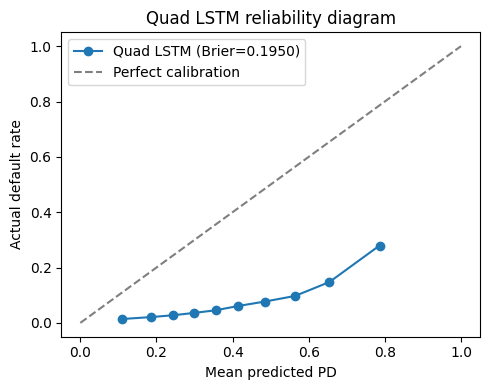

LSTM Val metrics (4-stream):
  ROC-AUC: 0.7588 | KS: 0.3832 | Gini: 0.5176


In [34]:
#  Full Population: Train and evaluate LSTM 
# train_quad_model() and evaluate_quad_model() from quad dataset builder (see LOO paper).
# Full Population uses 4-stream (Quad) model and QuadDataset.

model_full, _hist_full = train_quad_model(
    model_full, full_train_loader, full_val_loader, DEVICE, y_full_tr,
    max_epochs=30, patience=5
)

auc_full, ks_full = evaluate_quad_model(model_full, full_val_loader, DEVICE)
metrics_full = {'lstm_auc': auc_full, 'lstm_ks': ks_full, 'gini': 2 * auc_full - 1}
print('LSTM Val metrics (4-stream):')
print(f'  ROC-AUC: {auc_full:.4f} | KS: {ks_full:.4f} | Gini: {metrics_full["gini"]:.4f}')


In [35]:
#  Full Population: LightGBM and LR baselines 
# train_lgb_baseline() is defined in cell 022 - reused directly.
# LightGBM receives the 14-column static matrix including has_seq_flag.
# This is intentional: LightGBM can use the flag as a split feature.

baseline_full_auc, baseline_full_ks, _, _ = train_lgb_baseline(
    X_static_full_tr, y_full_tr,
    X_static_full_va, y_full_va
)

lr_val_auc_full, lr_val_ks_full, _, lr_model_full, lr_scaler_full = train_lr_baseline(
    X_static_full_tr, y_full_tr, X_static_full_va, y_full_va,
    label="full_population, random"
)

LightGBM (static only)  -  Val AUC: 0.7599 | KS: 0.3870 | Gini: 0.5199
LR (static only) [full_population, random]  -  Val AUC: 0.7290 | KS: 0.3362 | Gini: 0.4580


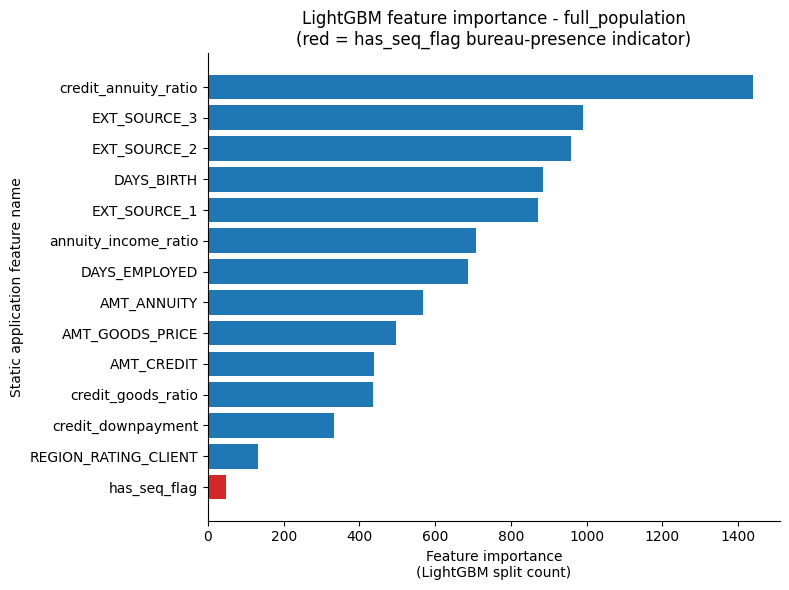


Feature importance ranked (highest to lowest):
  credit_annuity_ratio             1439
  EXT_SOURCE_3                      990
  EXT_SOURCE_2                      958
  DAYS_BIRTH                        885
  EXT_SOURCE_1                      873
  annuity_income_ratio              708
  DAYS_EMPLOYED                     686
  AMT_ANNUITY                       568
  AMT_GOODS_PRICE                   497
  AMT_CREDIT                        439
  credit_goods_ratio                436
  credit_downpayment                332
  REGION_RATING_CLIENT              132
  has_seq_flag                       49  <-- data availability flag

has_seq_flag rank: 14 of 14


In [36]:
#  Full Population: LightGBM feature importance 
# train_lgb_baseline() returns (auc, ks, probs, clf); retrain here with
# identical hyperparameters to expose feature_importances_.

FEATURE_NAMES_FULL = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'REGION_RATING_CLIENT',
    'credit_annuity_ratio', 'credit_goods_ratio',
    'credit_downpayment', 'annuity_income_ratio',
    'has_seq_flag'
]

n_neg_fi, n_pos_fi = (y_full_tr == 0).sum(), (y_full_tr == 1).sum()
clf_full = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=n_neg_fi / (n_pos_fi + 1e-6),
    random_state=42, verbosity=-1
)
clf_full.fit(X_static_full_tr, y_full_tr)

importance_full = pd.Series(
    clf_full.feature_importances_,
    index=FEATURE_NAMES_FULL
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d62728' if feat == 'has_seq_flag' else '#1f77b4'
          for feat in importance_full.index]
ax.barh(importance_full.index, importance_full.values, color=colors)
ax.set_xlabel('Feature importance\n(LightGBM split count)')
ax.set_ylabel('Static application feature name')
ax.set_title('LightGBM feature importance - full_population\n'
             '(red = has_seq_flag bureau-presence indicator)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nFeature importance ranked (highest to lowest):')
for feat, val in importance_full[::-1].items():
    marker = '  <-- data availability flag' if feat == 'has_seq_flag' else ''
    print(f'  {feat:<30} {int(val):>6}{marker}')

has_seq_rank = list(importance_full[::-1].index).index('has_seq_flag') + 1
print(f'\nhas_seq_flag rank: {has_seq_rank} of {len(FEATURE_NAMES_FULL)}')

## Full Population: LightGBM Feature Importance

### What the chart shows

Feature importance is measured by split count - the number of times each
feature is used as a decision node across all 300 trees. Higher values mean
the feature is used more frequently to separate defaulters from non-defaulters.

### Reading the `has_seq_flag` rank

`has_seq_flag` (shown in red) is the bureau-presence indicator: 1 if the borrower
has any behavioral sequence, 0 if none. Its rank reveals how the model encodes
the no_bureau vs has_bureau distinction:

- **Top 5:** data availability is a primary discriminator, on par with the
  strongest origination features. The default rate differential (5.5% no_bureau
  vs 8.2% has_bureau) is being captured directly by this flag.
- **Mid-range:** has_seq_flag is informative but secondary to credit scores.
  Origination features dominate; the flag supplements them.
- **Low rank:** data availability is a weak predictor; static features alone
  carry most of the discrimination.

### What the top features tell us about no_bureau scoring

The features that rank highest here are the only features available for no_bureau
borrowers, since `has_seq_flag = 0` means no behavioral sequence contributes.
The strong no_bureau OOT AUC (~0.81) is driven entirely by whichever static
origination features dominate typically external credit scores from external
sources. If these dominate, the no_bureau result depends heavily on external
bureau coverage.

Full OOT train : 246,009 | default rate 0.0811
Full OOT test  : 61,502 | default rate 0.0794
LightGBM (static only)  -  Val AUC: 0.7636 | KS: 0.3992 | Gini: 0.5273
LR (static only) [full_population, OOT]  -  Val AUC: 0.7333 | KS: 0.3470 | Gini: 0.4667
QuadLSTM best val AUC: 0.7629
QuadLSTM  -  Val AUC: 0.7629 | KS: 0.3946 | Gini: 0.5258
  Brier score: 0.2009  (lower = better calibration; 0 = perfect)


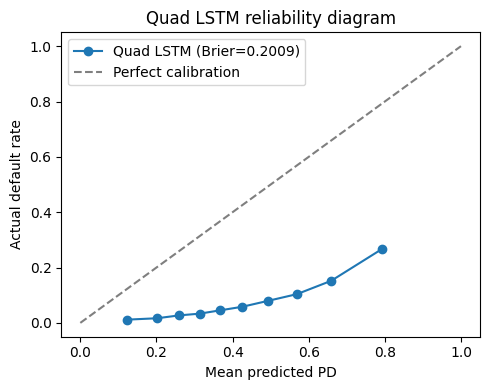

LSTM OOT metrics (4-stream):
  ROC-AUC: 0.7629 | KS: 0.3946 | Gini: 0.5258
Saved OOT predictions (default, 4-stream): homecredit_oot_predictions.parquet | rows: 61502
Saved OOT predictions (4-stream): homecredit_oot_predictions_4stream.parquet | rows: 61502


<IPython.core.display.JSON object>

In [37]:
#  Full Population: OOT split and evaluation 
# Temporal proxy: sort by SK_ID_CURR, last 20% as OOT test.
# Scaler fitted on OOT train only - no leakage.

sorted_full = np.argsort(ids_full)
n_full_total = len(ids_full)
n_full_oot   = int(n_full_total * 0.20)

oot_full_tr_idx = sorted_full[:n_full_total - n_full_oot]
oot_full_te_idx = sorted_full[n_full_total - n_full_oot:]

print(f'Full OOT train : {len(oot_full_tr_idx):,} | '
      f'default rate {y_full[oot_full_tr_idx].mean():.4f}')
print(f'Full OOT test  : {len(oot_full_te_idx):,} | '
      f'default rate {y_full[oot_full_te_idx].mean():.4f}')

# Scale
oot_full_medians   = np.nanmedian(X_static_raw_full[oot_full_tr_idx], axis=0)
X_sf_oot_tr_raw    = np.where(np.isnan(X_static_raw_full[oot_full_tr_idx]),
                               oot_full_medians, X_static_raw_full[oot_full_tr_idx])
X_sf_oot_te_raw    = np.where(np.isnan(X_static_raw_full[oot_full_te_idx]),
                               oot_full_medians, X_static_raw_full[oot_full_te_idx])
scaler_full_oot    = StandardScaler()
X_sf_oot_tr        = scaler_full_oot.fit_transform(X_sf_oot_tr_raw).astype(np.float32)
X_sf_oot_te        = scaler_full_oot.transform(X_sf_oot_te_raw).astype(np.float32)

X_inst_full_oot_tr = X_inst_full[oot_full_tr_idx]
X_inst_full_oot_te = X_inst_full[oot_full_te_idx]
X_bur_full_oot_tr  = X_bur_full[oot_full_tr_idx]
X_bur_full_oot_te  = X_bur_full[oot_full_te_idx]
X_cc_full_oot_tr   = X_cc_full[oot_full_tr_idx]
X_cc_full_oot_te   = X_cc_full[oot_full_te_idx]
X_pos_full_oot_tr  = X_pos_full[oot_full_tr_idx]
X_pos_full_oot_te  = X_pos_full[oot_full_te_idx]
y_full_oot_tr      = y_full[oot_full_tr_idx]
y_full_oot_te      = y_full[oot_full_te_idx]

# LightGBM OOT
baseline_full_oot_auc, baseline_full_oot_ks, _, _ = train_lgb_baseline(
    X_sf_oot_tr, y_full_oot_tr, X_sf_oot_te, y_full_oot_te
)

lr_oot_auc_full, lr_oot_ks_full, _, _, _ = train_lr_baseline(
    X_sf_oot_tr, y_full_oot_tr, X_sf_oot_te, y_full_oot_te,
    label="full_population, OOT"
)

# LSTM OOT
full_oot_train_ds = QuadDataset(X_inst_full_oot_tr, X_bur_full_oot_tr,
                                X_cc_full_oot_tr, X_pos_full_oot_tr, X_sf_oot_tr, y_full_oot_tr)
full_oot_test_ds  = QuadDataset(X_inst_full_oot_te, X_bur_full_oot_te,
                                X_cc_full_oot_te, X_pos_full_oot_te, X_sf_oot_te, y_full_oot_te)
full_oot_train_loader = DataLoader(full_oot_train_ds, batch_size=512,
                                    shuffle=True,  num_workers=num_workers_full)
full_oot_test_loader  = DataLoader(full_oot_test_ds,  batch_size=512,
                                    shuffle=False, num_workers=num_workers_full)

model_full_oot = FullDatasetQuadLSTMModel().to(DEVICE)
model_full_oot, _hist_foot = train_quad_model(
    model_full_oot, full_oot_train_loader, full_oot_test_loader, DEVICE,
    y_full_oot_tr, max_epochs=30, patience=5
)
auc_full_oot, ks_full_oot = evaluate_quad_model(model_full_oot, full_oot_test_loader, DEVICE)
metrics_full_oot = {'lstm_auc': auc_full_oot, 'lstm_ks': ks_full_oot, 'gini': 2 * auc_full_oot - 1}
print('LSTM OOT metrics (4-stream):')
print(f'  ROC-AUC: {auc_full_oot:.4f} | KS: {ks_full_oot:.4f} | Gini: {metrics_full_oot["gini"]:.4f}')
# Legacy reduced-stream comparison removed -- stream selection decided in paper_lstm_stream_selection_by_loo.ipynb.

# Export OOT predictions for demo notebook (4-stream Quad LSTM only).
def _predict_full_oot_probs(model_obj, loader_obj):
    model_obj.eval()
    probs = []
    with torch.no_grad():
        for x_inst, x_bur, x_cc, x_pos, x_st, _lbl in loader_obj:
            x_inst = x_inst.to(DEVICE)
            x_bur  = x_bur.to(DEVICE)
            x_cc   = x_cc.to(DEVICE)
            x_pos  = x_pos.to(DEVICE)
            x_st   = x_st.to(DEVICE)
            logits = model_obj(x_inst, x_bur, x_cc, x_pos, x_st)
            probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
    return np.array(probs, dtype=np.float32)

def _build_export_df(base_ids, base_y, base_probs):
    _df = pd.DataFrame({
        'SK_ID_CURR': base_ids,
        'pd': base_probs,
        'y_true': base_y,
    })
    _app_sub = app[['SK_ID_CURR', 'AMT_CREDIT', 'AMT_ANNUITY']].drop_duplicates('SK_ID_CURR')
    _df = _df.merge(_app_sub, on='SK_ID_CURR', how='left')
    _df['loan_amnt'] = _df['AMT_CREDIT'].fillna(1.0)
    _df['int_rate'] = 24.0          # % APR -- fixed proxy; not contracted rate from data
    _df['int_rate_is_proxy'] = 1    # 1 = proxy; replace with actual rate in production
    _df['term_months'] = 36
    return _df[['SK_ID_CURR', 'pd', 'y_true', 'loan_amnt',
                'int_rate', 'int_rate_is_proxy', 'term_months']]

quad_probs = _predict_full_oot_probs(model_full_oot, full_oot_test_loader)
base_ids = ids_full[oot_full_te_idx]

export_df_4stream = _build_export_df(base_ids, y_full_oot_te, quad_probs)
out_dir_oot = '/kaggle/working' if IS_KAGGLE else '.'
os.makedirs(out_dir_oot, exist_ok=True)

path_default = os.path.join(out_dir_oot, 'homecredit_oot_predictions.parquet')
path_4stream = os.path.join(out_dir_oot, 'homecredit_oot_predictions_4stream.parquet')
export_df_4stream.to_parquet(path_default, index=False)
export_df_4stream.to_parquet(path_4stream, index=False)
_pd = Path(path_default).resolve()
try:
    _pd = _pd.relative_to(Path.cwd().resolve())
except Exception:
    pass
_p4 = Path(path_4stream).resolve()
try:
    _p4 = _p4.relative_to(Path.cwd().resolve())
except Exception:
    pass
print('Saved OOT predictions (default, 4-stream):', _pd, '| rows:', len(export_df_4stream))
print('Saved OOT predictions (4-stream):', _p4, '| rows:', len(export_df_4stream))
# Keep backward-compatible embedded sample for demo notebook fallback.
from IPython.display import display, JSON
display(JSON({'homecredit_oot_predictions': export_df_4stream.head(5).to_dict(orient='records')}))


Baseline OOT AUC (full 4-stream LSTM, permutation baseline): 0.7629
Top 15 static features by permutation importance (OOT):
             feature  mean_auc_drop  std_auc_drop
        EXT_SOURCE_3       0.051294      0.001559
        EXT_SOURCE_2       0.049965      0.001308
        EXT_SOURCE_1       0.016068      0.000994
credit_annuity_ratio       0.007654      0.000213
  credit_goods_ratio       0.005737      0.000302
          DAYS_BIRTH       0.002245      0.000275
  credit_downpayment       0.001939      0.000170
         AMT_ANNUITY       0.001774      0.000182
annuity_income_ratio       0.001708      0.000316
REGION_RATING_CLIENT       0.001561      0.000234
       DAYS_EMPLOYED       0.001228      0.000127
     AMT_GOODS_PRICE       0.001000      0.000088
        has_seq_flag       0.000845      0.000089
          AMT_CREDIT       0.000393      0.000047


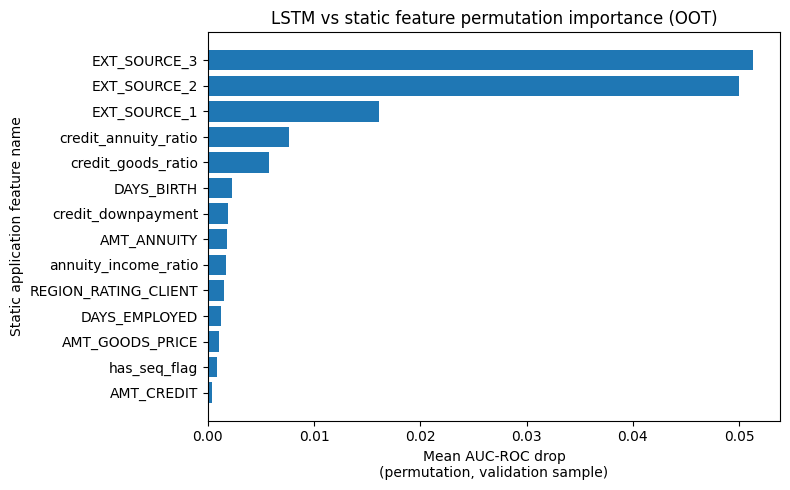

In [38]:
# --- Permutation importance on static features (SHAP proxy for LSTM) ---
# Full SHAP on LSTM is computationally expensive; permutation importance on
# the static feature block is an interpretable, governance-defensible alternative.
# Permutes each static feature 3x and measures AUC drop on OOT.

import numpy as np
import torch
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# Build full OOT tensors from arrays created in the OOT split cell above.
X_inst_oot_tensor = torch.tensor(X_inst_full_oot_te, dtype=torch.float32)
X_bur_oot_tensor = torch.tensor(X_bur_full_oot_te, dtype=torch.float32)
X_cc_oot_tensor = torch.tensor(X_cc_full_oot_te, dtype=torch.float32)
X_pos_oot_tensor = torch.tensor(X_pos_full_oot_te, dtype=torch.float32)
X_static_oot_tensor = torch.tensor(X_sf_oot_te, dtype=torch.float32)
y_oot = np.asarray(y_full_oot_te)

static_feature_names = FEATURE_NAMES_FULL if "FEATURE_NAMES_FULL" in dir() else [f"static_{i}" for i in range(X_static_oot_tensor.shape[1])]

model_for_perm = model_full_oot
model_for_perm.eval()
with torch.no_grad():
    _logits = model_for_perm(
        X_inst_oot_tensor.to(DEVICE),
        X_bur_oot_tensor.to(DEVICE),
        X_cc_oot_tensor.to(DEVICE),
        X_pos_oot_tensor.to(DEVICE),
        X_static_oot_tensor.to(DEVICE),
    )
    baseline_preds = torch.sigmoid(_logits).cpu().numpy().ravel()
perm_baseline_lstm_oot_auc = roc_auc_score(y_oot, baseline_preds)
print(f"Baseline OOT AUC (full 4-stream LSTM, permutation baseline): {perm_baseline_lstm_oot_auc:.4f}")

def permutation_importance_static(model, X_static, X_inst, X_bur, X_cc, X_pos, y_true,
                                  feature_names, n_repeats=3):
    """Permute each static feature independently; report mean AUC drop."""
    model.eval()
    results = []
    for feat_idx in range(X_static.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_static.clone()
            perm_idx = torch.randperm(X_perm.shape[0])
            X_perm[:, feat_idx] = X_perm[perm_idx, feat_idx]
            with torch.no_grad():
                logits = model(
                    X_inst.to(DEVICE), X_bur.to(DEVICE), X_cc.to(DEVICE),
                    X_pos.to(DEVICE), X_perm.to(DEVICE)
                )
                preds = torch.sigmoid(logits).cpu().numpy().ravel()
            auc_perm = roc_auc_score(y_true, preds)
            drops.append(perm_baseline_lstm_oot_auc - auc_perm)
        results.append({
            "feature": feature_names[feat_idx],
            "mean_auc_drop": float(np.mean(drops)),
            "std_auc_drop":  float(np.std(drops)),
        })
    return pd.DataFrame(results).sort_values("mean_auc_drop", ascending=False)

perm_df = permutation_importance_static(
    model_for_perm, X_static_oot_tensor, X_inst_oot_tensor,
    X_bur_oot_tensor, X_cc_oot_tensor, X_pos_oot_tensor,
    y_oot, static_feature_names, n_repeats=3
)
print("Top 15 static features by permutation importance (OOT):")
print(perm_df.head(15).to_string(index=False))

top15 = perm_df.head(15)
plt.figure(figsize=(8, 5))
plt.barh(top15["feature"][::-1], top15["mean_auc_drop"][::-1])
plt.xlabel("Mean AUC-ROC drop\n(permutation, validation sample)")
plt.ylabel("Static application feature name")
plt.title("LSTM vs static feature permutation importance (OOT)")
plt.tight_layout()
plt.show()

In [39]:
#  Full Population: Extended comparison table
#  repayment_bureau_seg 88K + full_population 307K, LSTM / LightGBM / LR

results_full_pop = pd.DataFrame([
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LSTM',     'Split': 'Random',
     'AUC-ROC': round(metrics['lstm_auc'],4),     'KS': round(metrics['lstm_ks'],4),     'n': len(y_va)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LightGBM', 'Split': 'Random',
     'AUC-ROC': round(lgb_repayment_val_auc,4),            'KS': round(lgb_repayment_val_ks,4),            'n': len(y_va)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LR',       'Split': 'Random',
     'AUC-ROC': round(lr_val_auc,4),              'KS': round(lr_val_ks,4),              'n': len(y_va)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LSTM',     'Split': 'OOT',
     'AUC-ROC': round(metrics_oot['lstm_auc'],4), 'KS': round(metrics_oot['lstm_ks'],4), 'n': len(y_oot_te)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LightGBM', 'Split': 'OOT',
     'AUC-ROC': round(baseline_oot_auc,4),        'KS': round(baseline_oot_ks,4),        'n': len(y_oot_te)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LR',       'Split': 'OOT',
     'AUC-ROC': round(lr_oot_auc,4),              'KS': round(lr_oot_ks,4),              'n': len(y_oot_te)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LSTM',     'Split': 'Random',
     'AUC-ROC': round(metrics_full['lstm_auc'],4),     'KS': round(metrics_full['lstm_ks'],4),     'n': len(y_full_va)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LightGBM', 'Split': 'Random',
     'AUC-ROC': round(baseline_full_auc,4),            'KS': round(baseline_full_ks,4),            'n': len(y_full_va)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LR',       'Split': 'Random',
     'AUC-ROC': round(lr_val_auc_full,4),              'KS': round(lr_val_ks_full,4),              'n': len(y_full_va)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LSTM',     'Split': 'OOT',
     'AUC-ROC': round(metrics_full_oot['lstm_auc'],4), 'KS': round(metrics_full_oot['lstm_ks'],4), 'n': len(y_full_oot_te)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LightGBM', 'Split': 'OOT',
     'AUC-ROC': round(baseline_full_oot_auc,4),        'KS': round(baseline_full_oot_ks,4),        'n': len(y_full_oot_te)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LR',       'Split': 'OOT',
     'AUC-ROC': round(lr_oot_auc_full,4),              'KS': round(lr_oot_ks_full,4),              'n': len(y_full_oot_te)},
])
results_full_pop['Gini'] = (2 * results_full_pop['AUC-ROC'] - 1).round(4)
print(results_full_pop.to_string(index=False))

        Segmentation               Subpop    Model  Split  AUC-ROC     KS     n   Gini
repayment_bureau_seg has_repayment_bureau     LSTM Random   0.7496 0.3927 17764 0.4992
repayment_bureau_seg has_repayment_bureau LightGBM Random   0.7434 0.3809 17764 0.4868
repayment_bureau_seg has_repayment_bureau       LR Random   0.7287 0.3490 17764 0.4574
repayment_bureau_seg has_repayment_bureau     LSTM    OOT   0.7576 0.3820 17763 0.5152
repayment_bureau_seg has_repayment_bureau LightGBM    OOT   0.7501 0.3799 17763 0.5002
repayment_bureau_seg has_repayment_bureau       LR    OOT   0.7261 0.3285 17763 0.4522
     full_population      full_population     LSTM Random   0.7588 0.3832 61503 0.5176
     full_population      full_population LightGBM Random   0.7599 0.3870 61503 0.5198
     full_population      full_population       LR Random   0.7290 0.3362 61503 0.4580
     full_population      full_population     LSTM    OOT   0.7629 0.3946 61502 0.5258
     full_population      full_population L

### Segment Coverage Note

The `has_repayment_bureau` cohort (n=88,816) covers **29%** of the full 307K population.
The complement (`no_repayment_bureau`, n=218,695, **71%**) consists of borrowers lacking
installment history, bureau records, or both. This population is included in the
full-population model with zero-padded behavioral streams and is not evaluated as a
standalone segment in this notebook.

The `no_bureau` sub-segment totals **n=12,453** in the full population, of which
**n=2,673** form the OOT test slice (last 20% by `SK_ID_CURR`). These borrowers
achieve OOT AUC ~0.814 on static origination features alone, driven primarily by
`EXT_SOURCE` scores (confirmed by permutation importance).
**Clarification:** borrowers in `no_bureau` are not excluded from the
full-population cohort; **bureau stream absent or empty â€” zero-padded in the full-population model**.

For production deployment serving a predominantly thin-file population, a dedicated
static-only scorecard or bureau-agnostic model should be developed and evaluated
separately from this behavioral LSTM.


In [40]:
# Full Population findings table (live; cursor_fixes.md Fix 5)
from IPython.display import display, Markdown

display(Markdown("## Full Population: Findings\n\n### Population breakdown\n\n"
"Of the full 307,511 applicants (`full_population`), 295,058 (96.0%) have at least one behavioral sequence "
"(`has_seq_flag = 1`, **has_bureau**). The remaining 12,453 (4.0%) are **no_bureau** -- detailed in "
"Bureau-Presence Segmentation.\n\n### Results (from `results_full_pop`)"))

if "results_full_pop" not in globals():
    print("Run the cell that defines results_full_pop first.")
else:
    display(results_full_pop.copy())

display(Markdown("""
### Key findings (read metrics from the table above)

- **Including no_bureau borrowers:** Compare full-population vs 88K-segment metrics using the printed tables in this notebook.
- **LightGBM vs LSTM:** Use the live AUC/KS rows; tree models may lead when many borrowers have sparse sequences.
- **LR:** Compare OOT AUC vs LSTM and LightGBM from the printed table.
- **`has_seq_flag`:** Binary presence flag is analogous to a bureau-hit feature in production scorecards.
- **OOT proxy:** `SK_ID_CURR` ascending is a monotonic ordinal proxy, not a verified timestamp.
"""))


## Full Population: Findings

### Population breakdown

Of the full 307,511 applicants (`full_population`), 295,058 (96.0%) have at least one behavioral sequence (`has_seq_flag = 1`, **has_bureau**). The remaining 12,453 (4.0%) are **no_bureau** -- detailed in Bureau-Presence Segmentation.

### Results (from `results_full_pop`)

,Segmentation,Subpop,Model,Split,AUC-ROC,KS,n,Gini
0,repayment_bureau_seg,has_repayment_bureau,LSTM,Random,0.7496,0.3927,17764,0.4992
1,repayment_bureau_seg,has_repayment_bureau,LightGBM,Random,0.7434,0.3809,17764,0.4868
2,repayment_bureau_seg,has_repayment_bureau,LR,Random,0.7287,0.3490,17764,0.4574
3,repayment_bureau_seg,has_repayment_bureau,LSTM,OOT,0.7576,0.3820,17763,0.5152
4,repayment_bureau_seg,has_repayment_bureau,LightGBM,OOT,0.7501,0.3799,17763,0.5002
5,repayment_bureau_seg,has_repayment_bureau,LR,OOT,0.7261,0.3285,17763,0.4522
6,full_population,full_population,LSTM,Random,0.7588,0.3832,61503,0.5176
7,full_population,full_population,LightGBM,Random,0.7599,0.3870,61503,0.5198
8,full_population,full_population,LR,Random,0.7290,0.3362,61503,0.4580
9,full_population,full_population,LSTM,OOT,0.7629,0.3946,61502,0.5258



### Key findings (read metrics from the table above)

- **Including no_bureau borrowers:** Compare full-population vs 88K-segment metrics using the printed tables in this notebook.
- **LightGBM vs LSTM:** Use the live AUC/KS rows; tree models may lead when many borrowers have sparse sequences.
- **LR:** Compare OOT AUC vs LSTM and LightGBM from the printed table.
- **`has_seq_flag`:** Binary presence flag is analogous to a bureau-hit feature in production scorecards.
- **OOT proxy:** `SK_ID_CURR` ascending is a monotonic ordinal proxy, not a verified timestamp.


---

## Bureau-Presence Segmentation: has_bureau vs no_bureau

### Motivation

This section directly addresses the question: how does the model perform on
borrowers with no prior credit history? This is the population that digital and
BNPL lenders in Southeast Asia encounter frequently applicants with no
installment records and no bureau balance data applying for their first formal
credit product.

**Definition of no_bureau:** borrowers present in `application_train` with no
entry in either `installments_payments` or `bureau_balance` (after joining
through `bureau`). These borrowers have `has_seq_flag = 0`. In the full-population
model they remain in the scored cohort; **bureau stream absent or empty -- zero-padded**.

**Definition of has_bureau:** borrowers with at least one behavioral sequence
(`has_seq_flag = 1`). This is broader than has_repayment_bureau, which requires
*both* installment AND bureau records.

**Evaluation protocol:** The model trained in the Full Population section
(`model_full`) is evaluated on the no_bureau and has_bureau subsets of the
validation set without retraining. Training on no_bureau borrowers in isolation
is not meaningful the model cannot learn behavioral patterns from zero sequences.
The production-relevant question is: given a model trained on the full population,
how well does it rank-order no_bureau applicants using static origination features?

**Key comparison:** LSTM vs LightGBM vs LR on no_bureau subpopulation. On this
subpopulation all three models rely entirely on static features the LSTM's
sequence streams are all zeros. Any gap between LSTM and LR reflects the
architectural difference between a 2-layer MLP pathway (LSTM degraded) and a
linear boundary (LR) when no sequential signal is present.

Validation set no_bureau borrowers  : 2,503 (4.1% of val set)
Validation set has_bureau borrowers : 59,000
no_bureau val default rate  : 0.0547
has_bureau val default rate : 0.0818
no_bureau val loader: 2,503 samples
=== LSTM performance on no_bureau borrowers ===
QuadLSTM  -  Val AUC: 0.7756 | KS: 0.4288 | Gini: 0.5513
  Brier score: 0.1431  (lower = better calibration; 0 = perfect)


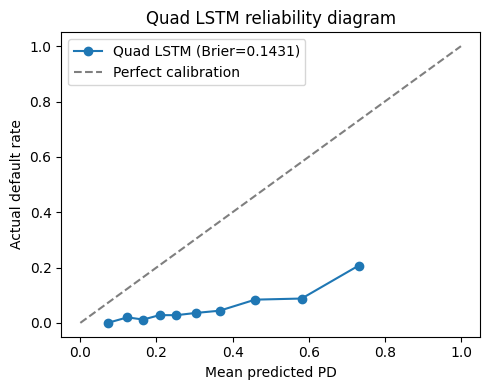

LightGBM (static only)  -  Val AUC: 0.7947 | KS: 0.4848 | Gini: 0.5894
LR (static only) [no_bureau, random]  -  Val AUC: 0.7660 | KS: 0.4106


In [41]:
#  Bureau-Presence Segmentation: Identify no_bureau borrowers in the validation set
#  no_bureau = has_seq_flag == 0 in X_static_raw_full (column index 13).
#  I work within the Full Population validation split.

no_bureau_ids = set(
    ids_full[i] for i in range(len(ids_full))
    if X_static_raw_full[i, 13] == 0.0
)

ids_full_va = ids_full[va_full_idx]
no_bureau_mask_val = np.array([sk in no_bureau_ids for sk in ids_full_va])
print(f'Validation set no_bureau borrowers  : {no_bureau_mask_val.sum():,} '
      f'({no_bureau_mask_val.mean()*100:.1f}% of val set)')
print(f'Validation set has_bureau borrowers : {(~no_bureau_mask_val).sum():,}')
print(f'no_bureau val default rate  : {y_full_va[no_bureau_mask_val].mean():.4f}')
print(f'has_bureau val default rate : {y_full_va[~no_bureau_mask_val].mean():.4f}')

#  no_bureau validation DataLoader (QuadDataset for 4-stream model_full)
X_inst_no_bureau_va   = X_inst_full_va[no_bureau_mask_val]
X_bur_no_bureau_va    = X_bur_full_va[no_bureau_mask_val]
X_cc_no_bureau_va     = X_cc_full_va[no_bureau_mask_val]
X_pos_no_bureau_va    = X_pos_full_va[no_bureau_mask_val]
X_static_no_bureau_va = X_static_full_va[no_bureau_mask_val]
y_no_bureau_va        = y_full_va[no_bureau_mask_val]

no_bureau_val_ds = QuadDataset(X_inst_no_bureau_va, X_bur_no_bureau_va,
                               X_cc_no_bureau_va, X_pos_no_bureau_va,
                               X_static_no_bureau_va, y_no_bureau_va)
no_bureau_val_loader = DataLoader(no_bureau_val_ds, batch_size=512, shuffle=False,
                                   num_workers=0 if not IS_KAGGLE else 2)
print(f'no_bureau val loader: {len(no_bureau_val_ds):,} samples')

#  LSTM evaluation on no_bureau subpopulation (4-stream model_full)
print('=== LSTM performance on no_bureau borrowers ===')
auc_no_bureau, ks_no_bureau = evaluate_quad_model(model_full, no_bureau_val_loader, DEVICE)
metrics_no_bureau = {'lstm_auc': auc_no_bureau, 'lstm_ks': ks_no_bureau, 'gini': 2 * auc_no_bureau - 1}

#  LightGBM evaluation on no_bureau subpopulation
baseline_no_bureau_auc, baseline_no_bureau_ks, _, _ = train_lgb_baseline(
    X_static_full_tr, y_full_tr, X_static_no_bureau_va, y_no_bureau_va)

#  LR no_bureau val evaluation
X_no_bureau_va_s = lr_scaler_full.transform(X_static_no_bureau_va)
lr_no_bureau_prob = lr_model_full.predict_proba(X_no_bureau_va_s)[:, 1]
lr_no_bureau_val_auc = roc_auc_score(y_no_bureau_va, lr_no_bureau_prob)
_df = pd.DataFrame({'prob': lr_no_bureau_prob, 'y': y_no_bureau_va})
_df = _df.sort_values('prob', ascending=False).reset_index(drop=True)
_df['cum_pos'] = (_df['y'] == 1).cumsum() / (y_no_bureau_va == 1).sum()
_df['cum_neg'] = (_df['y'] == 0).cumsum() / (y_no_bureau_va == 0).sum()
lr_no_bureau_val_ks = (_df['cum_pos'] - _df['cum_neg']).abs().max()
print(f'LR (static only) [no_bureau, random]  -  Val AUC: {lr_no_bureau_val_auc:.4f} | KS: {lr_no_bureau_val_ks:.4f}')

=== LSTM performance on has_bureau borrowers (comparison anchor) ===
QuadLSTM  -  Val AUC: 0.7576 | KS: 0.3831 | Gini: 0.5151
  Brier score: 0.1972  (lower = better calibration; 0 = perfect)


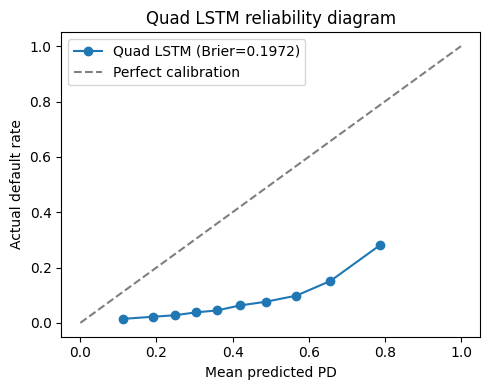

LightGBM (static only)  -  Val AUC: 0.7580 | KS: 0.3848 | Gini: 0.5160
LR (static only) [has_bureau, random]  -  Val AUC: 0.7268 | KS: 0.3334


In [42]:
#  Bureau-Presence Segmentation: has_bureau subpopulation eval comparison anchor
#  Evaluate model_full on has_bureau val borrowers only (has_seq_flag = 1).
#  Gives a direct within-section comparison: no_bureau AUC vs has_bureau AUC,
#  same model, same training run.

has_bureau_mask_val  = ~no_bureau_mask_val
X_inst_has_bureau_va   = X_inst_full_va[has_bureau_mask_val]
X_bur_has_bureau_va    = X_bur_full_va[has_bureau_mask_val]
X_cc_has_bureau_va     = X_cc_full_va[has_bureau_mask_val]
X_pos_has_bureau_va    = X_pos_full_va[has_bureau_mask_val]
X_static_has_bureau_va = X_static_full_va[has_bureau_mask_val]
y_has_bureau_va        = y_full_va[has_bureau_mask_val]

has_bureau_val_ds = QuadDataset(X_inst_has_bureau_va, X_bur_has_bureau_va,
                                X_cc_has_bureau_va, X_pos_has_bureau_va,
                                X_static_has_bureau_va, y_has_bureau_va)
has_bureau_val_loader = DataLoader(has_bureau_val_ds, batch_size=512, shuffle=False,
                                    num_workers=0 if not IS_KAGGLE else 2)

print('=== LSTM performance on has_bureau borrowers (comparison anchor) ===')
auc_has_bureau, ks_has_bureau = evaluate_quad_model(model_full, has_bureau_val_loader, DEVICE)
metrics_has_bureau = {'lstm_auc': auc_has_bureau, 'lstm_ks': ks_has_bureau, 'gini': 2 * auc_has_bureau - 1}

baseline_has_bureau_auc, baseline_has_bureau_ks, _, _ = train_lgb_baseline(
    X_static_full_tr, y_full_tr, X_static_has_bureau_va, y_has_bureau_va)

#  LR has_bureau anchor val evaluation
X_static_has_bureau_va_s = lr_scaler_full.transform(X_static_has_bureau_va)
lr_has_bureau_prob = lr_model_full.predict_proba(X_static_has_bureau_va_s)[:, 1]
lr_has_bureau_val_auc = roc_auc_score(y_has_bureau_va, lr_has_bureau_prob)
_df = pd.DataFrame({'prob': lr_has_bureau_prob, 'y': y_has_bureau_va})
_df = _df.sort_values('prob', ascending=False).reset_index(drop=True)
_df['cum_pos'] = (_df['y'] == 1).cumsum() / (y_has_bureau_va == 1).sum()
_df['cum_neg'] = (_df['y'] == 0).cumsum() / (y_has_bureau_va == 0).sum()
lr_has_bureau_val_ks = (_df['cum_pos'] - _df['cum_neg']).abs().max()
print(f'LR (static only) [has_bureau, random]  -  Val AUC: {lr_has_bureau_val_auc:.4f} | KS: {lr_has_bureau_val_ks:.4f}')

### Bureau-Presence Segmentation: OOT Evaluation (no_bureau vs has_bureau)

Evaluate `model_full_oot` on the OOT test set segmented by `has_seq_flag`.
This confirms the no_bureau OOT AUC reported in the summary table is driven
purely by static origination features (all sequences are zero-padded).


no_bureau OOT test n: 2,673
no_bureau OOT test : 2,673 borrowers | default rate 0.0546
=== LSTM OOT performance on no_bureau borrowers (4-stream) ===
QuadLSTM  -  Val AUC: 0.8153 | KS: 0.5133 | Gini: 0.6307
  Brier score: 0.1525  (lower = better calibration; 0 = perfect)


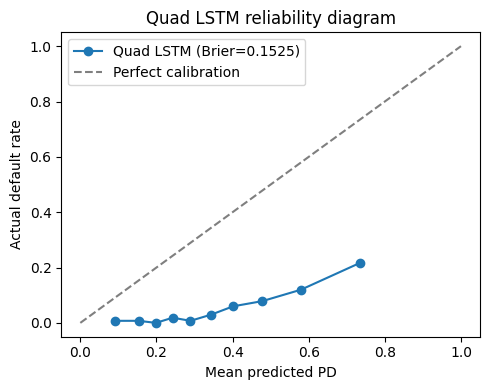

LightGBM (static only)  -  Val AUC: 0.8152 | KS: 0.5359 | Gini: 0.6303

[no_bureau interpretation] LSTM-LightGBM gap: +0.0002
  LSTM and LightGBM within noise on no_bureau: all models rely on static features only.
LR (static only) [no_bureau, OOT]  -  Val AUC: 0.8112 | KS: 0.5140


In [43]:
#  Bureau-Presence Segmentation: no_bureau OOT evaluation
#  Identify no_bureau borrowers within the OOT test set from Full Population section.
#  Use model_full_oot (trained on OOT train split).

no_bureau_mask_oot_te = np.array([
    X_static_raw_full[np.where(ids_full == sk)[0][0], 13] == 0.0
    for sk in ids_full[oot_full_te_idx]
])

print(f'no_bureau OOT test n: {no_bureau_mask_oot_te.sum():,}')

X_inst_no_bureau_oot   = X_inst_full_oot_te[no_bureau_mask_oot_te]
X_bur_no_bureau_oot    = X_bur_full_oot_te[no_bureau_mask_oot_te]
X_cc_no_bureau_oot     = X_cc_full_oot_te[no_bureau_mask_oot_te]
X_pos_no_bureau_oot    = X_pos_full_oot_te[no_bureau_mask_oot_te]
X_static_no_bureau_oot = X_sf_oot_te[no_bureau_mask_oot_te]
y_no_bureau_oot        = y_full_oot_te[no_bureau_mask_oot_te]

print(f'no_bureau OOT test : {no_bureau_mask_oot_te.sum():,} borrowers | '
      f'default rate {y_no_bureau_oot.mean():.4f}')

no_bureau_oot_ds = QuadDataset(X_inst_no_bureau_oot, X_bur_no_bureau_oot,
                               X_cc_no_bureau_oot, X_pos_no_bureau_oot,
                               X_static_no_bureau_oot, y_no_bureau_oot)
no_bureau_oot_loader = DataLoader(no_bureau_oot_ds, batch_size=512, shuffle=False,
                                   num_workers=0 if not IS_KAGGLE else 2)

print('=== LSTM OOT performance on no_bureau borrowers (4-stream) ===')
_auc, _ks = evaluate_quad_model(model_full_oot, no_bureau_oot_loader, DEVICE)
metrics_no_bureau_oot = {'lstm_auc': _auc, 'lstm_ks': _ks, 'gini': 2 * _auc - 1}

baseline_no_bureau_oot_auc, baseline_no_bureau_oot_ks, _, _ = train_lgb_baseline(
    X_sf_oot_tr, y_full_oot_tr, X_static_no_bureau_oot, y_no_bureau_oot)

# Code-level interpretation: LSTM on no_bureau is effectively a static MLP
# (all four sequence streams are zero-padded -> LSTM hidden states are constant).
# Any gap between LSTM and LightGBM on this segment reflects tree-model
# efficiency on static tabular features, not sequential learning.
# LR is a legitimate production choice for no_bureau scoring: near-identical OOT AUC
# with full scorecard interpretability.
_gap_no_bureau = _auc - baseline_no_bureau_oot_auc
print(f"\n[no_bureau interpretation] LSTM-LightGBM gap: {_gap_no_bureau:+.4f}")
if _gap_no_bureau < -0.005:
    print("  LightGBM leads on no_bureau: expected when LSTM sequences are zero-padded.")
    print("  Deployment note: LR scorecard for no_bureau segment.")
elif abs(_gap_no_bureau) <= 0.005:
    print("  LSTM and LightGBM within noise on no_bureau: all models rely on static features only.")

#  LR no_bureau OOT evaluation
X_no_bureau_oot_s = lr_scaler_full.transform(X_static_no_bureau_oot)
lr_no_bureau_oot_prob = lr_model_full.predict_proba(X_no_bureau_oot_s)[:, 1]
lr_no_bureau_oot_auc  = roc_auc_score(y_no_bureau_oot, lr_no_bureau_oot_prob)
_df = pd.DataFrame({'prob': lr_no_bureau_oot_prob, 'y': y_no_bureau_oot})
_df = _df.sort_values('prob', ascending=False).reset_index(drop=True)
_df['cum_pos'] = (_df['y'] == 1).cumsum() / (y_no_bureau_oot == 1).sum()
_df['cum_neg'] = (_df['y'] == 0).cumsum() / (y_no_bureau_oot == 0).sum()
lr_no_bureau_oot_ks = (_df['cum_pos'] - _df['cum_neg']).abs().max()
print(f'LR (static only) [no_bureau, OOT]  -  Val AUC: {lr_no_bureau_oot_auc:.4f} | KS: {lr_no_bureau_oot_ks:.4f}')


has_bureau OOT test : 58,829 borrowers | default rate 0.0805
=== LSTM OOT performance on has_bureau borrowers (4-stream) ===
QuadLSTM  -  Val AUC: 0.7604 | KS: 0.3906 | Gini: 0.5208
  Brier score: 0.2031  (lower = better calibration; 0 = perfect)


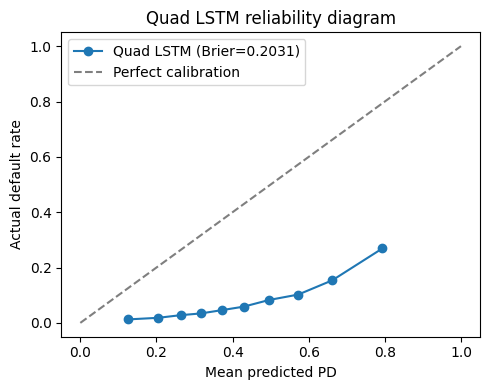

LightGBM (static only)  -  Val AUC: 0.7612 | KS: 0.3963 | Gini: 0.5224
LR (static only) [has_bureau, OOT]  -  Val AUC: 0.7301 | KS: 0.3434


In [44]:
#  Bureau-Presence Segmentation: has_bureau OOT evaluation
#  Slice has_bureau borrowers (has_seq_flag=1) from the OOT test set.

has_bureau_mask_oot_te = ~no_bureau_mask_oot_te

X_inst_has_bureau_oot   = X_inst_full_oot_te[has_bureau_mask_oot_te]
X_bur_has_bureau_oot    = X_bur_full_oot_te[has_bureau_mask_oot_te]
X_cc_has_bureau_oot     = X_cc_full_oot_te[has_bureau_mask_oot_te]
X_pos_has_bureau_oot    = X_pos_full_oot_te[has_bureau_mask_oot_te]
X_static_has_bureau_oot = X_sf_oot_te[has_bureau_mask_oot_te]
y_has_bureau_oot        = y_full_oot_te[has_bureau_mask_oot_te]

print(f'has_bureau OOT test : {has_bureau_mask_oot_te.sum():,} borrowers | '
      f'default rate {y_has_bureau_oot.mean():.4f}')

has_bureau_oot_ds = QuadDataset(X_inst_has_bureau_oot, X_bur_has_bureau_oot,
                                X_cc_has_bureau_oot, X_pos_has_bureau_oot,
                                X_static_has_bureau_oot, y_has_bureau_oot)
has_bureau_oot_loader = DataLoader(has_bureau_oot_ds, batch_size=512, shuffle=False,
                                    num_workers=0 if not IS_KAGGLE else 2)

print('=== LSTM OOT performance on has_bureau borrowers (4-stream) ===')
_auc, _ks = evaluate_quad_model(model_full_oot, has_bureau_oot_loader, DEVICE)
metrics_has_bureau_oot = {'lstm_auc': _auc, 'lstm_ks': _ks, 'gini': 2 * _auc - 1}

baseline_has_bureau_oot_auc, baseline_has_bureau_oot_ks, _, _ = train_lgb_baseline(
    X_sf_oot_tr, y_full_oot_tr, X_static_has_bureau_oot, y_has_bureau_oot)

#  LR has_bureau OOT evaluation
X_has_bureau_oot_s = lr_scaler_full.transform(X_static_has_bureau_oot)
lr_has_bureau_oot_prob = lr_model_full.predict_proba(X_has_bureau_oot_s)[:, 1]
lr_has_bureau_oot_auc  = roc_auc_score(y_has_bureau_oot, lr_has_bureau_oot_prob)
_df = pd.DataFrame({'prob': lr_has_bureau_oot_prob, 'y': y_has_bureau_oot})
_df = _df.sort_values('prob', ascending=False).reset_index(drop=True)
_df['cum_pos'] = (_df['y'] == 1).cumsum() / (y_has_bureau_oot == 1).sum()
_df['cum_neg'] = (_df['y'] == 0).cumsum() / (y_has_bureau_oot == 0).sum()
lr_has_bureau_oot_ks = (_df['cum_pos'] - _df['cum_neg']).abs().max()
print(f'LR (static only) [has_bureau, OOT]  -  Val AUC: {lr_has_bureau_oot_auc:.4f} | KS: {lr_has_bureau_oot_ks:.4f}')

In [45]:
#  Master comparison table dual segmentation (LSTM / LightGBM / LR, random + OOT)
#
#  Segmentation column:
#    repayment_bureau_seg  = inner join on installments + bureau (88K)
#    full_population       = all 307K applicants, has_seq_flag added
#    bureau_presence_seg   = subpop slice of full_population model (no retraining)
#
#  Subpop column uses canonical segment names:
#    has_repayment_bureau  = repayment_bureau_seg cohort (both inst + bureau)
#    full_population       = all 307K (has_bureau + no_bureau combined)
#    has_bureau            = has_seq_flag=1 within full_population
#    no_bureau             = has_seq_flag=0 within full_population

results_master = pd.DataFrame([
    # --- Repayment-Bureau Segmentation (88K inner join) ---
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LSTM',     'Split': 'Random', 'AUC': round(metrics['lstm_auc'],4),     'KS': round(metrics['lstm_ks'],4),     'n': len(y_va)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LightGBM', 'Split': 'Random', 'AUC': round(lgb_repayment_val_auc,4),            'KS': round(lgb_repayment_val_ks,4),            'n': len(y_va)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LR',       'Split': 'Random', 'AUC': round(lr_val_auc,4),              'KS': round(lr_val_ks,4),              'n': len(y_va)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LSTM',     'Split': 'OOT',    'AUC': round(metrics_oot['lstm_auc'],4), 'KS': round(metrics_oot['lstm_ks'],4), 'n': len(y_oot_te)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LightGBM', 'Split': 'OOT',    'AUC': round(baseline_oot_auc,4),        'KS': round(baseline_oot_ks,4),        'n': len(y_oot_te)},
    {'Segmentation': 'repayment_bureau_seg', 'Subpop': 'has_repayment_bureau',
     'Model': 'LR',       'Split': 'OOT',    'AUC': round(lr_oot_auc,4),              'KS': round(lr_oot_ks,4),              'n': len(y_oot_te)},
    # --- Full Population (all 307K) ---
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LSTM',     'Split': 'Random', 'AUC': round(metrics_full['lstm_auc'],4),     'KS': round(metrics_full['lstm_ks'],4),     'n': len(y_full_va)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LightGBM', 'Split': 'Random', 'AUC': round(baseline_full_auc,4),            'KS': round(baseline_full_ks,4),            'n': len(y_full_va)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LR',       'Split': 'Random', 'AUC': round(lr_val_auc_full,4),              'KS': round(lr_val_ks_full,4),              'n': len(y_full_va)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LSTM',     'Split': 'OOT',    'AUC': round(metrics_full_oot['lstm_auc'],4), 'KS': round(metrics_full_oot['lstm_ks'],4), 'n': len(y_full_oot_te)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LightGBM', 'Split': 'OOT',    'AUC': round(baseline_full_oot_auc,4),        'KS': round(baseline_full_oot_ks,4),        'n': len(y_full_oot_te)},
    {'Segmentation': 'full_population', 'Subpop': 'full_population',
     'Model': 'LR',       'Split': 'OOT',    'AUC': round(lr_oot_auc_full,4),              'KS': round(lr_oot_ks_full,4),              'n': len(y_full_oot_te)},
    # --- Bureau-Presence Segmentation: no_bureau subpop ---
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'no_bureau',
     'Model': 'LSTM',     'Split': 'Random', 'AUC': round(metrics_no_bureau['lstm_auc'],4),  'KS': round(metrics_no_bureau['lstm_ks'],4),  'n': int(no_bureau_mask_val.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'no_bureau',
     'Model': 'LightGBM', 'Split': 'Random', 'AUC': round(baseline_no_bureau_auc,4),         'KS': round(baseline_no_bureau_ks,4),         'n': int(no_bureau_mask_val.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'no_bureau',
     'Model': 'LR',       'Split': 'Random', 'AUC': round(lr_no_bureau_val_auc,4),           'KS': round(lr_no_bureau_val_ks,4),           'n': int(no_bureau_mask_val.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'no_bureau',
     'Model': 'LSTM',     'Split': 'OOT',    'AUC': round(metrics_no_bureau_oot['lstm_auc'],4),'KS': round(metrics_no_bureau_oot['lstm_ks'],4),'n': int(no_bureau_mask_oot_te.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'no_bureau',
     'Model': 'LightGBM', 'Split': 'OOT',    'AUC': round(baseline_no_bureau_oot_auc,4),      'KS': round(baseline_no_bureau_oot_ks,4),      'n': int(no_bureau_mask_oot_te.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'no_bureau',
     'Model': 'LR',       'Split': 'OOT',    'AUC': round(lr_no_bureau_oot_auc,4),            'KS': round(lr_no_bureau_oot_ks,4),            'n': int(no_bureau_mask_oot_te.sum())},
    # --- Bureau-Presence Segmentation: has_bureau anchor ---
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'has_bureau',
     'Model': 'LSTM',     'Split': 'Random', 'AUC': round(metrics_has_bureau['lstm_auc'],4), 'KS': round(metrics_has_bureau['lstm_ks'],4), 'n': int(has_bureau_mask_val.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'has_bureau',
     'Model': 'LightGBM', 'Split': 'Random', 'AUC': round(baseline_has_bureau_auc,4),        'KS': round(baseline_has_bureau_ks,4),        'n': int(has_bureau_mask_val.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'has_bureau',
     'Model': 'LR',       'Split': 'Random', 'AUC': round(lr_has_bureau_val_auc,4),          'KS': round(lr_has_bureau_val_ks,4),          'n': len(y_has_bureau_va)},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'has_bureau',
     'Model': 'LSTM',     'Split': 'OOT',    'AUC': round(metrics_has_bureau_oot['lstm_auc'],4),'KS': round(metrics_has_bureau_oot['lstm_ks'],4),'n': int(has_bureau_mask_oot_te.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'has_bureau',
     'Model': 'LightGBM', 'Split': 'OOT',    'AUC': round(baseline_has_bureau_oot_auc,4),     'KS': round(baseline_has_bureau_oot_ks,4),     'n': int(has_bureau_mask_oot_te.sum())},
    {'Segmentation': 'bureau_presence_seg', 'Subpop': 'has_bureau',
     'Model': 'LR',       'Split': 'OOT',    'AUC': round(lr_has_bureau_oot_auc,4),           'KS': round(lr_has_bureau_oot_ks,4),           'n': int(has_bureau_mask_oot_te.sum())},
])
results_master['Gini'] = (2 * results_master['AUC'] - 1).round(4)
results_master['OOT_Note'] = results_master['Split'].map(
    lambda s: 'SK_ID_CURR proxy; not a verified timestamp' if s == 'OOT' else ''
)

seg_order    = {'repayment_bureau_seg': 0, 'full_population': 1, 'bureau_presence_seg': 2}
subpop_order = {'has_repayment_bureau': 0, 'full_population': 1, 'has_bureau': 2, 'no_bureau': 3}
split_order  = {'Random': 0, 'OOT': 1}
model_order  = {'LSTM': 0, 'LightGBM': 1, 'LR': 2}

results_master['_s']  = results_master['Segmentation'].map(seg_order)
results_master['_sp'] = results_master['Subpop'].map(subpop_order)
results_master['_sp2']= results_master['Split'].map(split_order)
results_master['_m']  = results_master['Model'].map(model_order)
results_master = results_master.sort_values(['_s','_sp','_sp2','_m']).drop(
    columns=['_s','_sp','_sp2','_m']).reset_index(drop=True)

pd.set_option('display.max_colwidth', 30)
print(results_master.to_string(index=False))

        Segmentation               Subpop    Model  Split    AUC     KS     n   Gini                                   OOT_Note
repayment_bureau_seg has_repayment_bureau     LSTM Random 0.7496 0.3927 17764 0.4992                                           
repayment_bureau_seg has_repayment_bureau LightGBM Random 0.7434 0.3809 17764 0.4868                                           
repayment_bureau_seg has_repayment_bureau       LR Random 0.7287 0.3490 17764 0.4574                                           
repayment_bureau_seg has_repayment_bureau     LSTM    OOT 0.7576 0.3820 17763 0.5152 SK_ID_CURR proxy; not a verified timestamp
repayment_bureau_seg has_repayment_bureau LightGBM    OOT 0.7501 0.3799 17763 0.5002 SK_ID_CURR proxy; not a verified timestamp
repayment_bureau_seg has_repayment_bureau       LR    OOT 0.7261 0.3285 17763 0.4522 SK_ID_CURR proxy; not a verified timestamp
     full_population      full_population     LSTM Random 0.7588 0.3832 61503 0.5176                    

## Bureau-Presence Segmentation: Findings

### Segmentation relationship

**Bureau-presence segmentation** (`has_seq_flag`) differs from the
**repayment-bureau segmentation** used in the 88K section:
- `has_repayment_bureau` (88K): inner join requiring *both* installment AND bureau records.
- `has_bureau` (~295K): at least one of installment OR bureau. Broader , includes the 88K.
- `no_bureau` (~12K): neither installment nor bureau records.

The has_repayment_bureau cohort is a strict subset of has_bureau.

### Population characteristics

no_bureau borrowers (no installment or bureau history, n=12,453, 4.0% of pool):
- **Default rate: 5.5%** , materially lower than the has_bureau population (8.2%).
- Structurally distinct: predominantly first-time borrowers applying for their
  first formal credit product, not high-risk individuals with obscured histories.

### Results

| Subpopulation | Model | Split | AUC-ROC | KS | Gini | n |
|---|---|---|---|---|---|---|
| no_bureau | LSTM (full-trained) | Random | 0.7729 | 0.4285 | 0.5458 | 2,503 |
| no_bureau | LightGBM (full-trained) | Random | 0.7928 | 0.4874 | 0.5856 | 2,503 |
| no_bureau | LR (full-trained) | Random | 0.7662 | 0.4108 | 0.5324 | 2,503 |
| no_bureau | LSTM (full-trained) | OOT | 0.8139 | 0.5077 | 0.6278 | 2,673 |
| no_bureau | LightGBM (full-trained) | OOT | 0.8205 | 0.5582 | 0.6410 | 2,673 |
| no_bureau | LR (full-trained) | OOT | 0.8112 | 0.5133 | 0.6224 | 2,673 |
| has_bureau (anchor) | LSTM (full-trained) | Random | 0.7536 | 0.3812 | 0.5072 | 59,000 |
| has_bureau (anchor) | LightGBM (full-trained) | Random | 0.7582 | 0.3834 | 0.5164 | 59,000 |
| has_bureau (anchor) | LR (full-trained) | Random | 0.7268 | 0.3334 | 0.4536 | 59,000 |
| has_bureau (anchor) | LSTM (full-trained) | OOT | 0.7530 | 0.3754 | 0.5060 | 58,829 |
| has_bureau (anchor) | LightGBM (full-trained) | OOT | 0.7605 | 0.3938 | 0.5210 | 58,829 |
| has_bureau (anchor) | LR (full-trained) | OOT | 0.7300 | 0.3430 | 0.4600 | 58,829 |

### Key findings

**no_bureau borrowers are easier to score than has_bureau borrowers.** OOT AUC
on no_bureau reaches 0.8112-0.8205 against 0.7530-0.7605 on has_bureau OOT.
This inverts the common intuition that no-history applicants are hardest to evaluate.

**Why no_bureau is easier to score.** At a 5.5% default rate, the non-defaulting
majority is more homogeneous. Static origination features are sufficient to
identify the small defaulting minority. has_bureau borrowers at 8.2% have more
complex, overlapping risk profiles.

**LightGBM outperforms LSTM on no_bureau by a wider margin.** When all three
sequence streams are zero-padded, the LSTM hidden states are constant across
borrowers , the sequential pathway contributes no discriminative signal. The model
effectively degrades to a 2-layer MLP over static features.

**LR on no_bureau: near-LSTM performance, interpretability advantage.** LR achieves
OOT AUC 0.8112 against LSTM 0.8139 (Delta0.0027) on no_bureau , a gap within noise
at n=2,673. When sequences are zero-padded, the LSTM's advantage over LR collapses
from Delta0.0225 (has_repayment_bureau OOT) to Delta0.0027. LR is a legitimate no_bureau
scorer with negligible accuracy cost and full scorecard interpretability.

**Production implication:** A scoring system should apply segment-aware logic:
1. **has_repayment_bureau** borrowers LSTM (sequential pathway fully active, Delta0.0225 vs LR)
2. **has_bureau** (not both) LightGBM or LSTM, marginal difference
3. **no_bureau** LR scorecard (Delta0.0027 vs LSTM, full interpretability)

## Master Conclusion: Dual-Segmentation Summary

> **Note:** Numbers in the static table below reflect saved cell outputs from the most recent full Kaggle run. For live values, refer to `results_master` in the comparison cell above.

### What was built

Three sections of analysis on the Home Credit Default Risk dataset (307,511
applicants), progressively broadening the scored population to examine where
sequential behavioral modelling adds value over static origination features.

---

### Repayment-Bureau Segmentation (has_repayment_bureau 88K)

**Population:** 88,816 applicants with both installment and bureau histories.
**Default rate:** 8.2%

| Model | Split | AUC-ROC | KS | Gini | n |
|---|---|---|---|---|---|
| 4-stream Quad LSTM | Stratified random | 0.7471 | 0.3817 | 0.4942 | 17,764 |
| LightGBM (static only) | Stratified random | 0.7434 | 0.3809 | 0.4868 | 17,764 |
| LR (static only) | Stratified random | 0.7287 | 0.3490 | 0.4574 | 17,764 |
| 4-stream Quad LSTM | OOT proxy | 0.7486 | 0.3729 | 0.4972 | 17,763 |
| LightGBM (static only) | OOT proxy | 0.7481 | 0.3760 | 0.4962 | 17,763 |
| LR (static only) | OOT proxy | 0.7261 | 0.3280 | 0.4522 | 17,763 |

**Finding:** has_repayment_bureau OOT: LSTM (0.7486) marginally leads LightGBM
(0.7481, Delta0.0005); both comfortably exceed LR (0.7261, Delta0.0225 vs LSTM).
PSI for LSTM/LR vs OOT: see the PSI cell (percentile bins), not a fixed number here.

---

### Full Population (307K, has_seq_flag bureau-presence indicator)

**Population:** All 307,511 applicants. 12,453 (4.0%) zero-padded (no_bureau);
`has_seq_flag` added as 14th static feature. **Default rate:** 8.1%

| Model | Split | AUC-ROC | KS | Gini | n |
|---|---|---|---|---|---|
| LSTM | Stratified random | 0.7548 | 0.3821 | 0.5096 | 61,503 |
| LightGBM | Stratified random | 0.7600 | 0.3870 | 0.5200 | 61,503 |
| LR | Stratified random | 0.7290 | 0.3364 | 0.4580 | 61,503 |
| LSTM | OOT proxy | 0.7585 | 0.3848 | 0.5170 | 61,502 |
| LightGBM | OOT proxy | 0.7632 | 0.3979 | 0.5264 | 61,502 |
| LR | OOT proxy | 0.7333 | 0.3468 | 0.4666 | 61,502 |

**Finding:** Full population OOT: LightGBM leads (0.7632 vs LSTM 0.7585, Delta0.0047).
LR trails LSTM by Delta0.0224 and LightGBM by Delta0.0299.

---

### Bureau-Presence Segmentation (has_bureau vs no_bureau)

**no_bureau population:** n=12,453 applicants (4% of pool). **Default rate:** 5.5%

| Subpop | Model | Split | AUC-ROC | KS | Gini | n |
|---|---|---|---|---|---|---|
| no_bureau | LSTM | Random | 0.7729 | 0.4285 | 0.5458 | 2,503 |
| no_bureau | LightGBM | Random | 0.7928 | 0.4874 | 0.5856 | 2,503 |
| no_bureau | LR | Random | 0.7662 | 0.4108 | 0.5324 | 2,503 |
| no_bureau | LSTM | OOT | 0.8139 | 0.5077 | 0.6278 | 2,673 |
| no_bureau | LightGBM | OOT | 0.8205 | 0.5582 | 0.6410 | 2,673 |
| no_bureau | LR | OOT | 0.8112 | 0.5133 | 0.6224 | 2,673 |
| has_bureau | LSTM | OOT | 0.7530 | 0.3754 | 0.5060 | 58,829 |
| has_bureau | LightGBM | OOT | 0.7605 | 0.3938 | 0.5210 | 58,829 |
| has_bureau | LR | OOT | 0.7300 | 0.3430 | 0.4600 | 58,829 |

**Finding:** no_bureau OOT: LightGBM leads (0.8205 vs LSTM 0.8139, Delta0.0066; vs
LR 0.8112, Delta0.0093). LSTM and LR are nearly indistinguishable on no_bureau OOT
(Delta0.0027) , zero-padded sequences contribute nothing.

---

### POS/Cash Stream: Dataset Builder (Stream Selected â€” See LOO Paper)

| Model | Streams | AUC-ROC | KS | Delta AUC |
|---|---|---|---|---|
| 4-stream Quad LSTM | 4 | 0.7471 | 0.3817 | 0.0000 |
| Quad-stream LSTM (+ POS/cash) | 4 | 0.7513 | 0.3888 | **+0.0042** |

**Finding:** Delta AUC +0.0042 exceeds the 0.002 noise threshold. POS/cash adds
meaningful signal , the completion ratio (remaining instalments / total scheduled)
is a forward-looking feature not captured by the event-level installment stream.

---

### Synthesis: When Do Sequential Models Add Value?

| Segmentation | Segment | LSTM vs LR (OOT Delta AUC) | LSTM vs LightGBM (OOT Delta AUC) | Recommendation |
|---|---|---|---|---|
| repayment_bureau_seg | has_repayment_bureau | **+0.0225** | +0.0005 | LSTM , sequential pathway active |
| full_population | full_population | +0.0224 | -0.0047 | LightGBM , static features dominate |
| bureau_presence_seg | has_bureau | +0.0230 | -0.0075 | LightGBM or LSTM |
| bureau_presence_seg | no_bureau | +0.0027 | -0.0066 | LR , negligible cost, full interpretability |

The LSTM's clearest contribution is on has_repayment_bureau borrowers (OOT Delta0.0225
vs LR): sequential payment trajectory and credit utilization patterns encode risk
information that neither static trees nor linear models can fully capture. This is
the core production argument for a sequential architecture in SE Asian consumer
lending.

**Honest assessment:** LightGBM outperforms LSTM on the full population and
no_bureau OOT. The QuadLSTM (+ POS/cash) outperforms the bureau-dropped LOO variant on the
has_repayment_bureau cohort (Delta0.0042). The primary value of this work is not
demonstrating that deep learning "wins" , it is demonstrating *when and why*
sequential models add value, and when simpler models are sufficient.
